# 📓 Notebook 06 — Evaluation & TensorBoard
**Spendly AI — Coding Camp 2026 powered by DBS Foundation (CC26-PSU276)**

Pipeline evaluasi konsolidasi semua model:
1. **Multimodal Classifier** (TF-IDF + CNN) — Accuracy, Classification Report, Confusion Matrix
2. **Forecaster** (LSTM + Attention) — MAE, RMSE, MAPE per kategori
3. **OCR** (CRNN + CTC) — CER, WER + visual sample
4. **Receipt Detector NB07** (Dual-Scale YOLO) — mAP summary (opsional)
5. **TensorBoard** — tampilan log dari semua model
6. **Batch Testing** — otomatis dari folder test per kategori
7. **Manual Testing** — upload satu gambar, prediksi langsung

> **Sync:** NB01 (split), NB02 (custom components), NB03 (classifier v2, 9 kelas),
> NB04 (forecaster v2), NB05 (OCR revised v5), NB07 (receipt detector final)

## 0 — Setup Environment

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 0 — Mount Google Drive & Set Working Directory
# ══════════════════════════════════════════════════════════════
import os

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print('Google Drive mounted')
except:
    print('Not on Colab or Drive already mounted')

# Auto-detect project root
POSSIBLE_PATHS = [
    '/content/drive/MyDrive/Capstone - Ai Eng - Spendly_ Workspace',
    '/content/drive/MyDrive/Colab Notebooks/Capstone - Ai Eng - Spendly_ Workspace',
    '/content/Capstone - Ai Eng - Spendly_ Workspace',
    os.path.abspath(os.path.join(os.getcwd(), '..')),  # lokal
    os.getcwd(),  # kalau CWD sudah di project root
]

PROJECT_ROOT = None
for p in POSSIBLE_PATHS:
    if os.path.isdir(os.path.join(p, 'data')) and os.path.isdir(os.path.join(p, 'src')):
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    # Cari di seluruh /content/drive/MyDrive/
    drive_root = '/content/drive/MyDrive'
    if os.path.isdir(drive_root):
        for d in os.listdir(drive_root):
            candidate = os.path.join(drive_root, d)
            if os.path.isdir(os.path.join(candidate, 'data')) and os.path.isdir(os.path.join(candidate, 'src')):
                PROJECT_ROOT = candidate
                break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Project folder tidak ditemukan! '
        'Pastikan folder Capstone - Ai Eng - Spendly_ Workspace ada di Google Drive.'
    )

os.chdir(os.path.join(PROJECT_ROOT, 'notebooks'))
import sys
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'CWD: {os.getcwd()}')
print(f'Data folders: {[d for d in os.listdir(os.path.join(PROJECT_ROOT, "data")) if os.path.isdir(os.path.join(PROJECT_ROOT, "data", d))]}')


In [1]:
import os
# Force CPU — hindari error 'DNN library not found' bila cuDNN tidak terinstall
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import os, sys, re, string, random, json, glob, warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import joblib
import cv2
import editdistance
from PIL import Image, ImageDraw, ImageFont
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────
# PROJECT_ROOT sudah di-set oleh mount cell di atas
try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')
LOGS_DIR     = os.path.join(PROJECT_ROOT, 'logs')
PROCESSED_DIR = os.path.join(DATA_DIR, '_processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

# ── Seed ─────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Kategori (sync NB03 v2 + NB04 v2) ───────────────────────
LABELS = [
    "Beauty", "F&B", "Gas", "Groceries",
    "Health", "HouseHold", "Lifestyle", "Listrik", "Transport"
]
LABEL_TO_IDX = {lbl: i for i, lbl in enumerate(LABELS)}
IDX_TO_LABEL = {i: lbl for i, lbl in enumerate(LABELS)}
NUM_CLASSES  = len(LABELS)   # 9

IMG_SIZE     = 224   # Classifier

# ── OCR konstanta (sync NB05 v5) ─────────────────────────────
CHARS_OCR     = (string.digits + string.ascii_uppercase
                + string.ascii_lowercase + ' .,:-/()%')
CHAR_TO_IDX_OCR = {c: i+1 for i, c in enumerate(CHARS_OCR)}
IDX_TO_CHAR_OCR = {v: k for k, v in CHAR_TO_IDX_OCR.items()}
BLANK_IDX_OCR   = len(CHARS_OCR) + 1   # 72
NUM_OCR_CHARS   = len(CHARS_OCR) + 2   # 73
OCR_IMG_W, OCR_IMG_H = 400, 50
MAX_LABEL_LEN_OCR    = 25

# ── Forecaster konstanta (sync NB04 v2) ──────────────────────
N_FEATURES_FORECAST = 9
LOOKBACK_F  = 12
CATEGORIES_FORECAST = [
    "Beauty", "F&B", "Gas", "Groceries",
    "Health", "HouseHold", "Lifestyle", "Listrik", "Transport"
]

print(f"TF : {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Kategori ({NUM_CLASSES}): {LABELS}")
print(f"CHARS_OCR   : {len(CHARS_OCR)} karakter | BLANK={BLANK_IDX_OCR} | TOTAL={NUM_OCR_CHARS}")

c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


TF : 2.10.1
GPU: []
PROJECT_ROOT: c:\Nizam\DBS-Foundation\Capstone - Ai Eng - Spendly_ Workspace
Kategori (9): ['Beauty', 'F&B', 'Gas', 'Groceries', 'Health', 'HouseHold', 'Lifestyle', 'Listrik', 'transport']
CHARS_OCR   : 71 karakter | BLANK=72 | TOTAL=73


---
## 6.1 — Multimodal Classifier Evaluation
**(NB03 v2: TF-IDF + NLP Sastrawi + CNN, 9 kelas)**

In [3]:
# ── 1a. NLPPreprocessor — WAJIB didefinisikan sebelum joblib.load ──
# Pickle menyimpan referensi class __main__.NLPPreprocessor
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

class NLPPreprocessor:
    """Pipeline NLP — identik NB03.
    1. lowercase + hapus noise + NUM token
    2. Stopword removal (PySastrawi)
    3. Stemming Bahasa Indonesia (PySastrawi)
    """
    def __init__(self):
        self.stopword_remover = StopWordRemoverFactory().create_stop_word_remover()
        self.stemmer          = StemmerFactory().create_stemmer()

    def preprocess(self, text: str) -> str:
        if not isinstance(text, str) or not text.strip():
            return ''
        text = text.lower()
        text = re.sub(r'[^a-z0-9\s]', ' ', text)
        text = re.sub(r'\d+', 'NUM', text)
        text = re.sub(r'\s+', ' ', text).strip()
        text = self.stopword_remover.remove(text)
        return self.stemmer.stem(text)

    def preprocess_batch(self, texts):
        return [self.preprocess(t) for t in texts]

print("✅ NLPPreprocessor defined")

✅ NLPPreprocessor defined


In [4]:
# ── 1b. Definisi arsitektur (identik NB03 v2: output 9 kelas) ──
def build_multimodal_classifier(n_text_features, n_classes=NUM_CLASSES, img_size=IMG_SIZE):
    text_input = tf.keras.Input(shape=(n_text_features,), name="text_input")
    t = layers.Dense(256, activation='relu')(text_input)
    t = layers.BatchNormalization()(t)
    t = layers.Dropout(0.4)(t)
    t = layers.Dense(128, activation='relu')(t)
    t = layers.Dropout(0.3)(t)

    img_input = tf.keras.Input(shape=(img_size, img_size, 3), name="image_input")
    c = layers.Conv2D(32, (3,3), activation='relu', padding='same')(img_input)
    c = layers.MaxPooling2D((2,2))(c)
    c = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c)
    c = layers.MaxPooling2D((2,2))(c)
    c = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c)
    c = layers.GlobalAveragePooling2D()(c)
    c = layers.Dense(128, activation='relu')(c)
    c = layers.Dropout(0.3)(c)

    fused   = layers.Concatenate()([t, c])
    f       = layers.Dense(256, activation='relu')(fused)
    f       = layers.BatchNormalization()(f)
    f       = layers.Dropout(0.4)(f)
    f       = layers.Dense(128, activation='relu')(f)
    outputs = layers.Dense(n_classes, activation='softmax', name="output")(f)
    return Model(inputs=[text_input, img_input], outputs=outputs,
                 name="spendly_multimodal_classifier")

print("✅ build_multimodal_classifier defined (9 kelas)")

✅ build_multimodal_classifier defined (9 kelas)


In [5]:
# ── 1c. Load artefak NB03 ──────────────────────────────────────
cls_tfidf_path   = os.path.join(MODELS_DIR, 'classifier', 'tfidf_vectorizer.joblib')
cls_nlp_path     = os.path.join(MODELS_DIR, 'classifier', 'nlp_preprocessor.joblib')
cls_keras_path   = os.path.join(MODELS_DIR, 'classifier', 'classifier.keras')
cls_weights_path = os.path.join(MODELS_DIR, 'classifier', 'classifier_weights.h5')

# TF-IDF
tfidf = joblib.load(cls_tfidf_path)
n_features = len(tfidf.vocabulary_)
print(f"✅ TF-IDF loaded  — vocab size: {n_features}")

# NLPPreprocessor
nlp_preprocessor = joblib.load(cls_nlp_path)
print("✅ NLPPreprocessor loaded")

# Model — prioritas: .keras > weights fallback
if os.path.exists(cls_keras_path):
    cls_model = tf.keras.models.load_model(cls_keras_path)
    print("✅ Classifier loaded dari classifier.keras")
elif os.path.exists(cls_weights_path):
    cls_model = build_multimodal_classifier(n_features)
    cls_model.load_weights(cls_weights_path)
    print("✅ Classifier loaded dari classifier_weights.h5 (fallback)")
else:
    raise FileNotFoundError(
        f"Model classifier tidak ditemukan. Jalankan NB03 dulu.\n"
        f"  Expected: {cls_keras_path}")

print(f"   Input : {[inp.shape for inp in cls_model.inputs]}")
print(f"   Output: {cls_model.output_shape}  (expected: (None, {NUM_CLASSES}))")

✅ TF-IDF loaded  — vocab size: 5000
✅ NLPPreprocessor loaded
✅ Classifier loaded dari classifier.keras
   Input : [TensorShape([None, 5000]), TensorShape([None, 224, 224, 3])]
   Output: (None, 9)  (expected: (None, 9))


In [6]:
# ── 1d. Load & prep data test ─────────────────────────────────
dataset_text = pd.read_csv(os.path.join(PROCESSED_DIR, 'dataset_text.csv'))
manifest     = pd.read_csv(os.path.join(DATA_DIR, '_csv', 'split_manifest.csv'))

has_blur     = 'is_blurry' in dataset_text.columns
filepath_col = 'image_path' if 'image_path' in dataset_text.columns else 'filepath'

dataset_text['filepath_norm'] = dataset_text[filepath_col].apply(
    lambda x: os.path.normpath(str(x)).lower())
manifest['filepath_norm'] = manifest['filepath'].apply(
    lambda x: os.path.normpath(str(x)).lower())

manifest_orig = (
    manifest[manifest.get('augmented', False) == False].copy()
    if 'augmented' in manifest.columns else manifest.copy())

merged = dataset_text.merge(
    manifest_orig[['filepath_norm', 'split']], on='filepath_norm', how='left')
merged['split']          = merged['split'].fillna('train')
merged['extracted_text'] = merged['extracted_text'].fillna('').astype(str)

train_data = merged[merged['split'] == 'train']
val_data   = merged[merged['split'] == 'val']
test_data  = merged[merged['split'] == 'test']

print(f"Split — train: {len(train_data)} | val: {len(val_data)} | test: {len(test_data)}")

# Fallback re-split IDENTIK NB03
if len(val_data) < 10 or len(test_data) < 10:
    print("⚠️  Val/Test terlalu kecil — re-splitting identik NB03")
    from sklearn.model_selection import train_test_split as _tts
    train_data, temp = _tts(merged, test_size=0.3, stratify=merged['category'], random_state=42)
    val_data, test_data = _tts(temp, test_size=0.5, stratify=temp['category'], random_state=42)
    print(f"Re-split — train: {len(train_data)} | val: {len(val_data)} | test: {len(test_data)}")

# NLP + TF-IDF
test_texts_nlp = nlp_preprocessor.preprocess_batch(
    test_data['extracted_text'].fillna('').tolist())
X_test_text = tfidf.transform(test_texts_nlp).toarray().astype(np.float32)
y_test_cls  = np.array([LABEL_TO_IDX[c] for c in test_data['category']])

if has_blur:
    X_test_text[test_data['is_blurry'].values] = 0.0
    print(f"Zeroed text for {test_data['is_blurry'].sum()} blurry images")

# Load images
def load_image(fp, size=(IMG_SIZE, IMG_SIZE)):
    img = cv2.imread(str(fp))
    if img is None:
        return np.zeros((size[0], size[1], 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, size).astype(np.float32) / 255.0

X_test_img = np.array([load_image(fp) for fp in test_data[filepath_col].values])
print(f"X_test_text: {X_test_text.shape} | X_test_img: {X_test_img.shape}")

Split — train: 577 | val: 124 | test: 124
Zeroed text for 2 blurry images
X_test_text: (124, 5000) | X_test_img: (124, 224, 224, 3)


In [7]:
# ── 1e. Predict & report ────────────────────────────────────────
cls_preds        = cls_model.predict([X_test_text, X_test_img], verbose=0)
cls_pred_classes = np.argmax(cls_preds, axis=1)
cls_acc          = float(np.mean(cls_pred_classes == y_test_cls))

print(f"\n{'='*60}")
print(f"MULTIMODAL CLASSIFIER TEST ACCURACY: {cls_acc:.4f} ({cls_acc*100:.2f}%)")
print(f"{'='*60}")
print(classification_report(
    y_test_cls, cls_pred_classes,
    target_names=LABELS, digits=4, zero_division=0))

target_met_cls = cls_acc >= 0.85
print(f"Target ≥ 85% — {'✅ PASSED' if target_met_cls else '⚠️ BELOW TARGET'}")


MULTIMODAL CLASSIFIER TEST ACCURACY: 0.9516 (95.16%)
              precision    recall  f1-score   support

      Beauty     1.0000    0.8889    0.9412         9
         F&B     0.9545    1.0000    0.9767        21
         Gas     1.0000    0.7778    0.8750         9
   Groceries     0.9474    0.9474    0.9474        38
      Health     1.0000    1.0000    1.0000         6
   HouseHold     1.0000    1.0000    1.0000         6
   Lifestyle     0.6667    1.0000    0.8000         6
     Listrik     1.0000    0.8889    0.9412         9
   transport     1.0000    1.0000    1.0000        20

    accuracy                         0.9516       124
   macro avg     0.9521    0.9448    0.9424       124
weighted avg     0.9600    0.9516    0.9526       124

Target ≥ 85% — ✅ PASSED


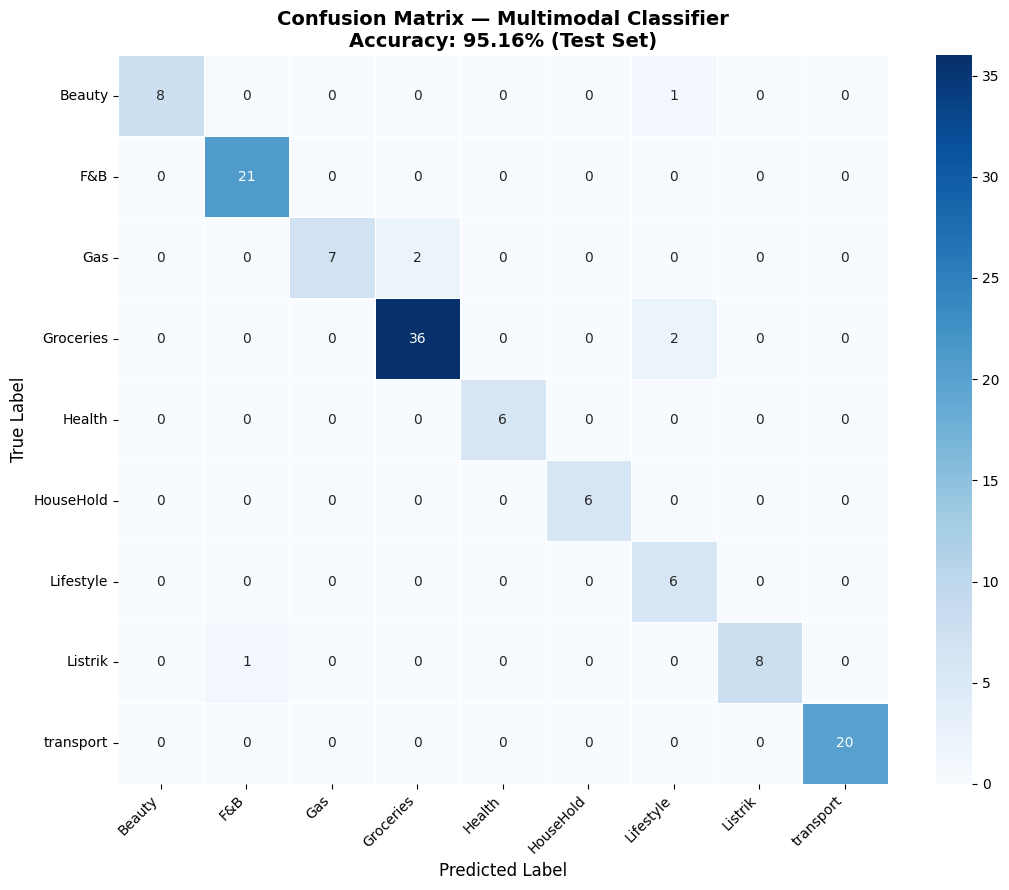

✅ Confusion Matrix tersimpan: data/_processed/eval_classifier_cm.png


In [8]:
# ── 1f. Confusion Matrix ────────────────────────────────────────
cm = confusion_matrix(y_test_cls, cls_pred_classes)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title(f'Confusion Matrix — Multimodal Classifier\nAccuracy: {cls_acc:.2%} (Test Set)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'eval_classifier_cm.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion Matrix tersimpan: data/_processed/eval_classifier_cm.png")

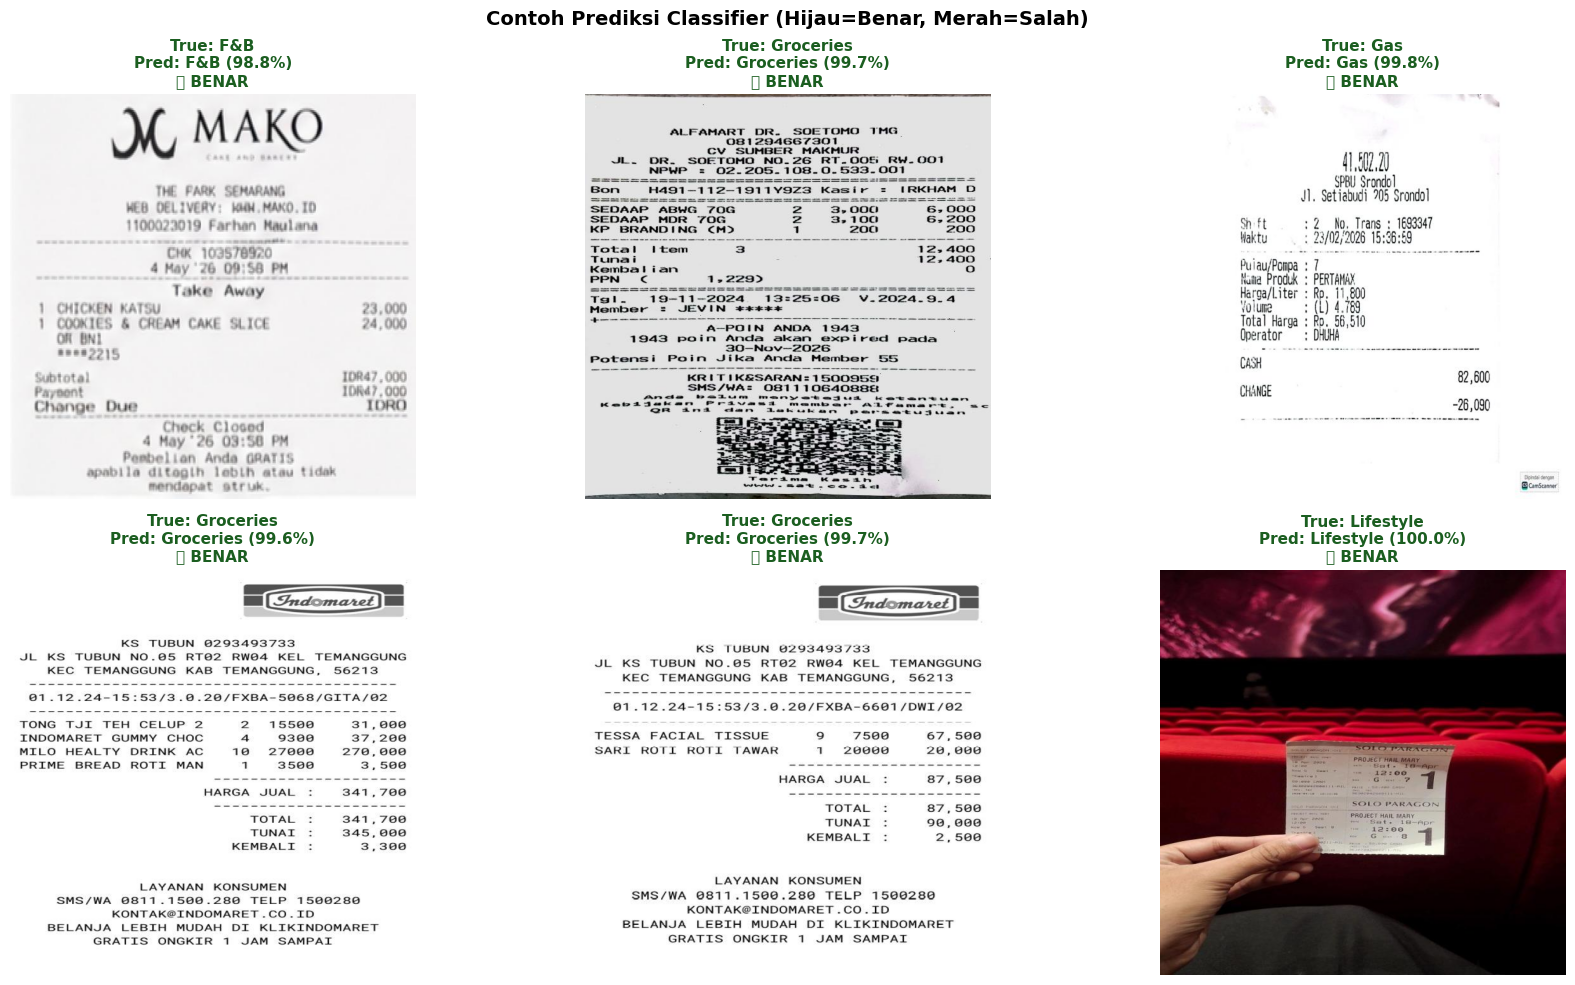

✅ Contoh prediksi tersimpan: data/_processed/eval_classifier_samples.png


In [9]:
# ── 1g. Visualisasi 6 contoh prediksi (gambar + label + confidence) ──
n_show = min(6, len(test_data))
sample_idx = np.random.choice(len(test_data), n_show, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, idx in enumerate(sample_idx):
    row      = test_data.iloc[idx]
    fp       = row[filepath_col]
    true_lbl = row['category']
    img_disp = cv2.imread(str(fp))
    if img_disp is None:
        axes[i].text(0.5, 0.5, 'Gambar tidak ditemukan', ha='center', va='center')
        axes[i].axis('off'); continue
    img_disp = cv2.cvtColor(img_disp, cv2.COLOR_BGR2RGB)

    pred_lbl = LABELS[cls_pred_classes[idx]]
    conf     = float(cls_preds[idx, cls_pred_classes[idx]])
    correct  = pred_lbl == true_lbl

    axes[i].imshow(img_disp)
    axes[i].axis('off')

    border_color = '#4CAF50' if correct else '#F44336'
    for spine in axes[i].spines.values():
        spine.set_edgecolor(border_color); spine.set_linewidth(4); spine.set_visible(True)

    title = (f"True: {true_lbl}\nPred: {pred_lbl} ({conf:.1%})\n"
             f"{'✅ BENAR' if correct else '❌ SALAH'}")
    axes[i].set_title(title, fontsize=11, fontweight='bold',
                      color='#1B5E20' if correct else '#B71C1C')

plt.suptitle('Contoh Prediksi Classifier (Hijau=Benar, Merah=Salah)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'eval_classifier_samples.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Contoh prediksi tersimpan: data/_processed/eval_classifier_samples.png")

---
## 6.2 — Forecaster Evaluation (LSTM + Attention)
**(NB04 v2: LSTM 64→32 + Custom Attention, 9 kategori)**

In [10]:
# ── 2a. AttentionLayer — identik NB04 ─────────────────────────
class AttentionLayer(tf.keras.layers.Layer):
    """Custom attention — identik NB04."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight('att_weight',
            shape=(input_shape[-1], input_shape[-1]), initializer='glorot_uniform')
        self.b = self.add_weight('att_bias',
            shape=(input_shape[-1],), initializer='zeros')
        self.u = self.add_weight('att_context',
            shape=(input_shape[-1],), initializer='glorot_uniform')

    def call(self, x):
        score = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        attn  = tf.nn.softmax(tf.tensordot(score, self.u, axes=1), axis=1)
        return tf.reduce_sum(x * tf.expand_dims(attn, -1), axis=1)

    def get_config(self):
        return super().get_config()


def build_forecaster(lookback=LOOKBACK_F, n_features=N_FEATURES_FORECAST):
    """LSTM(64→32) + Attention — identik NB04 v2 (9 output)."""
    inputs  = tf.keras.Input(shape=(lookback, n_features))
    x       = layers.LSTM(64, return_sequences=True)(inputs)
    x       = layers.LSTM(32, return_sequences=True)(x)
    x       = AttentionLayer(name='attention')(x)
    x       = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(n_features)(x)
    return tf.keras.Model(inputs, outputs, name='spendly_forecaster_attention_v2')

print("✅ AttentionLayer & build_forecaster defined (9 output)")

✅ AttentionLayer & build_forecaster defined (9 output)


In [11]:
# ── 2b. Load model forecaster ─────────────────────────────────
f_keras_path   = os.path.join(MODELS_DIR, 'forecaster', 'forecaster.keras')
f_weights_path = os.path.join(MODELS_DIR, 'forecaster', 'forecaster_weights.h5')

if os.path.exists(f_keras_path):
    f_model = tf.keras.models.load_model(
        f_keras_path, custom_objects={'AttentionLayer': AttentionLayer})
    print("✅ Forecaster loaded dari forecaster.keras")
elif os.path.exists(f_weights_path):
    f_model = build_forecaster()
    f_model.load_weights(f_weights_path)
    print("✅ Forecaster loaded dari forecaster_weights.h5 (fallback)")
else:
    raise FileNotFoundError(
        f"Model forecaster tidak ditemukan. Jalankan NB04 dulu.\n"
        f"  Expected: {f_keras_path}")

print(f"   Input : {f_model.input_shape}  (expected: (None,{LOOKBACK_F},{N_FEATURES_FORECAST}))")
print(f"   Output: {f_model.output_shape} (expected: (None,{N_FEATURES_FORECAST}))")

✅ Forecaster loaded dari forecaster.keras
   Input : (None, 12, 9)  (expected: (None,12,9))
   Output: (None, 9) (expected: (None,9))


In [12]:
# ── 2c. Load data & scaler — identik NB04 ────────────────────
spending_csv = os.path.join(DATA_DIR, '_csv', 'synthetic_spending.csv')
spending_df  = pd.read_csv(spending_csv, index_col=0)
print(f"Spending data shape: {spending_df.shape}")

scaler_path = os.path.join(MODELS_DIR, 'forecaster', 'scaler.joblib')
if os.path.exists(scaler_path):
    scaler = joblib.load(scaler_path)
    print("✅ Scaler loaded dari NB04 (fit on train only)")
else:
    print("⚠️ scaler.joblib tidak ditemukan — re-fit on train split")
    scaler = MinMaxScaler()
    raw_train = spending_df.values[:int(len(spending_df) * 0.8)]
    scaler.fit(raw_train)

scaled = scaler.transform(spending_df.values)

def create_sequences(data, lookback=LOOKBACK_F, horizon=1):
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback:i+lookback+horizon].flatten())
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled)
n_seq        = len(X_all)
seq_val_end  = int(n_seq * 0.9)
X_test_f     = X_all[seq_val_end:].astype(np.float32)
y_test_f     = y_all[seq_val_end:].astype(np.float32)

print(f"Sequences — total: {n_seq} | test split: {len(X_test_f)}")

Spending data shape: (520, 9)
✅ Scaler loaded dari NB04 (fit on train only)
Sequences — total: 508 | test split: 51


In [13]:
# ── 2d. Predict & per-category metrics ───────────────────────
f_preds      = f_model.predict(X_test_f, verbose=0)
f_preds_real = scaler.inverse_transform(f_preds)
f_trues_real = scaler.inverse_transform(y_test_f)

f_mae_norm   = float(np.mean(np.abs(f_preds - y_test_f)))
f_rmse_norm  = float(np.sqrt(np.mean((f_preds - y_test_f)**2)))

per_cat_metrics = []
print(f"\n{'Kategori':12s} {'MAE(norm)':>10s} {'MAE(Rp)':>14s} {'RMSE(Rp)':>14s} {'MAPE':>8s}")
print("-" * 60)
for idx, cat in enumerate(CATEGORIES_FORECAST):
    mae_n  = float(np.mean(np.abs(f_preds[:, idx] - y_test_f[:, idx])))
    mae_r  = float(np.mean(np.abs(f_preds_real[:, idx] - f_trues_real[:, idx])))
    rmse_r = float(np.sqrt(np.mean((f_preds_real[:, idx] - f_trues_real[:, idx])**2)))
    denom  = np.where(f_trues_real[:, idx] != 0, f_trues_real[:, idx], 1)
    mape   = float(np.mean(np.abs((f_trues_real[:, idx] - f_preds_real[:, idx]) / denom)) * 100)
    per_cat_metrics.append({'category': cat, 'mae_norm': mae_n,
                             'mae_rp': mae_r, 'rmse_rp': rmse_r, 'mape': mape})
    print(f"{cat:12s} {mae_n:10.5f} {mae_r:14,.0f} {rmse_r:14,.0f} {mape:7.2f}%")

print(f"\n{'OVERALL':12s} {f_mae_norm:10.5f}")
print(f"\nTarget MAE (normalized) ≤ 0.02 — {'✅ PASSED' if f_mae_norm <= 0.02 else '⚠️ ABOVE TARGET'} ({f_mae_norm:.5f})")
target_met_f = f_mae_norm <= 0.02


Kategori      MAE(norm)        MAE(Rp)       RMSE(Rp)     MAPE
------------------------------------------------------------
Beauty          0.01432            818          1,040    0.49%
F&B             0.01273          2,370          2,998    0.44%
Gas             0.01693          1,261          1,562    0.57%
Groceries       0.01221          3,647          4,534    0.42%
Health          0.01621            616            733    0.58%
HouseHold       0.01460          1,640          2,044    0.50%
Lifestyle       0.01536          1,428          1,832    0.52%
Listrik         0.01540          2,011          2,388    0.53%
Transport       0.01918          1,309          1,570    0.67%

OVERALL         0.01522

Target MAE (normalized) ≤ 0.02 — ✅ PASSED (0.01522)


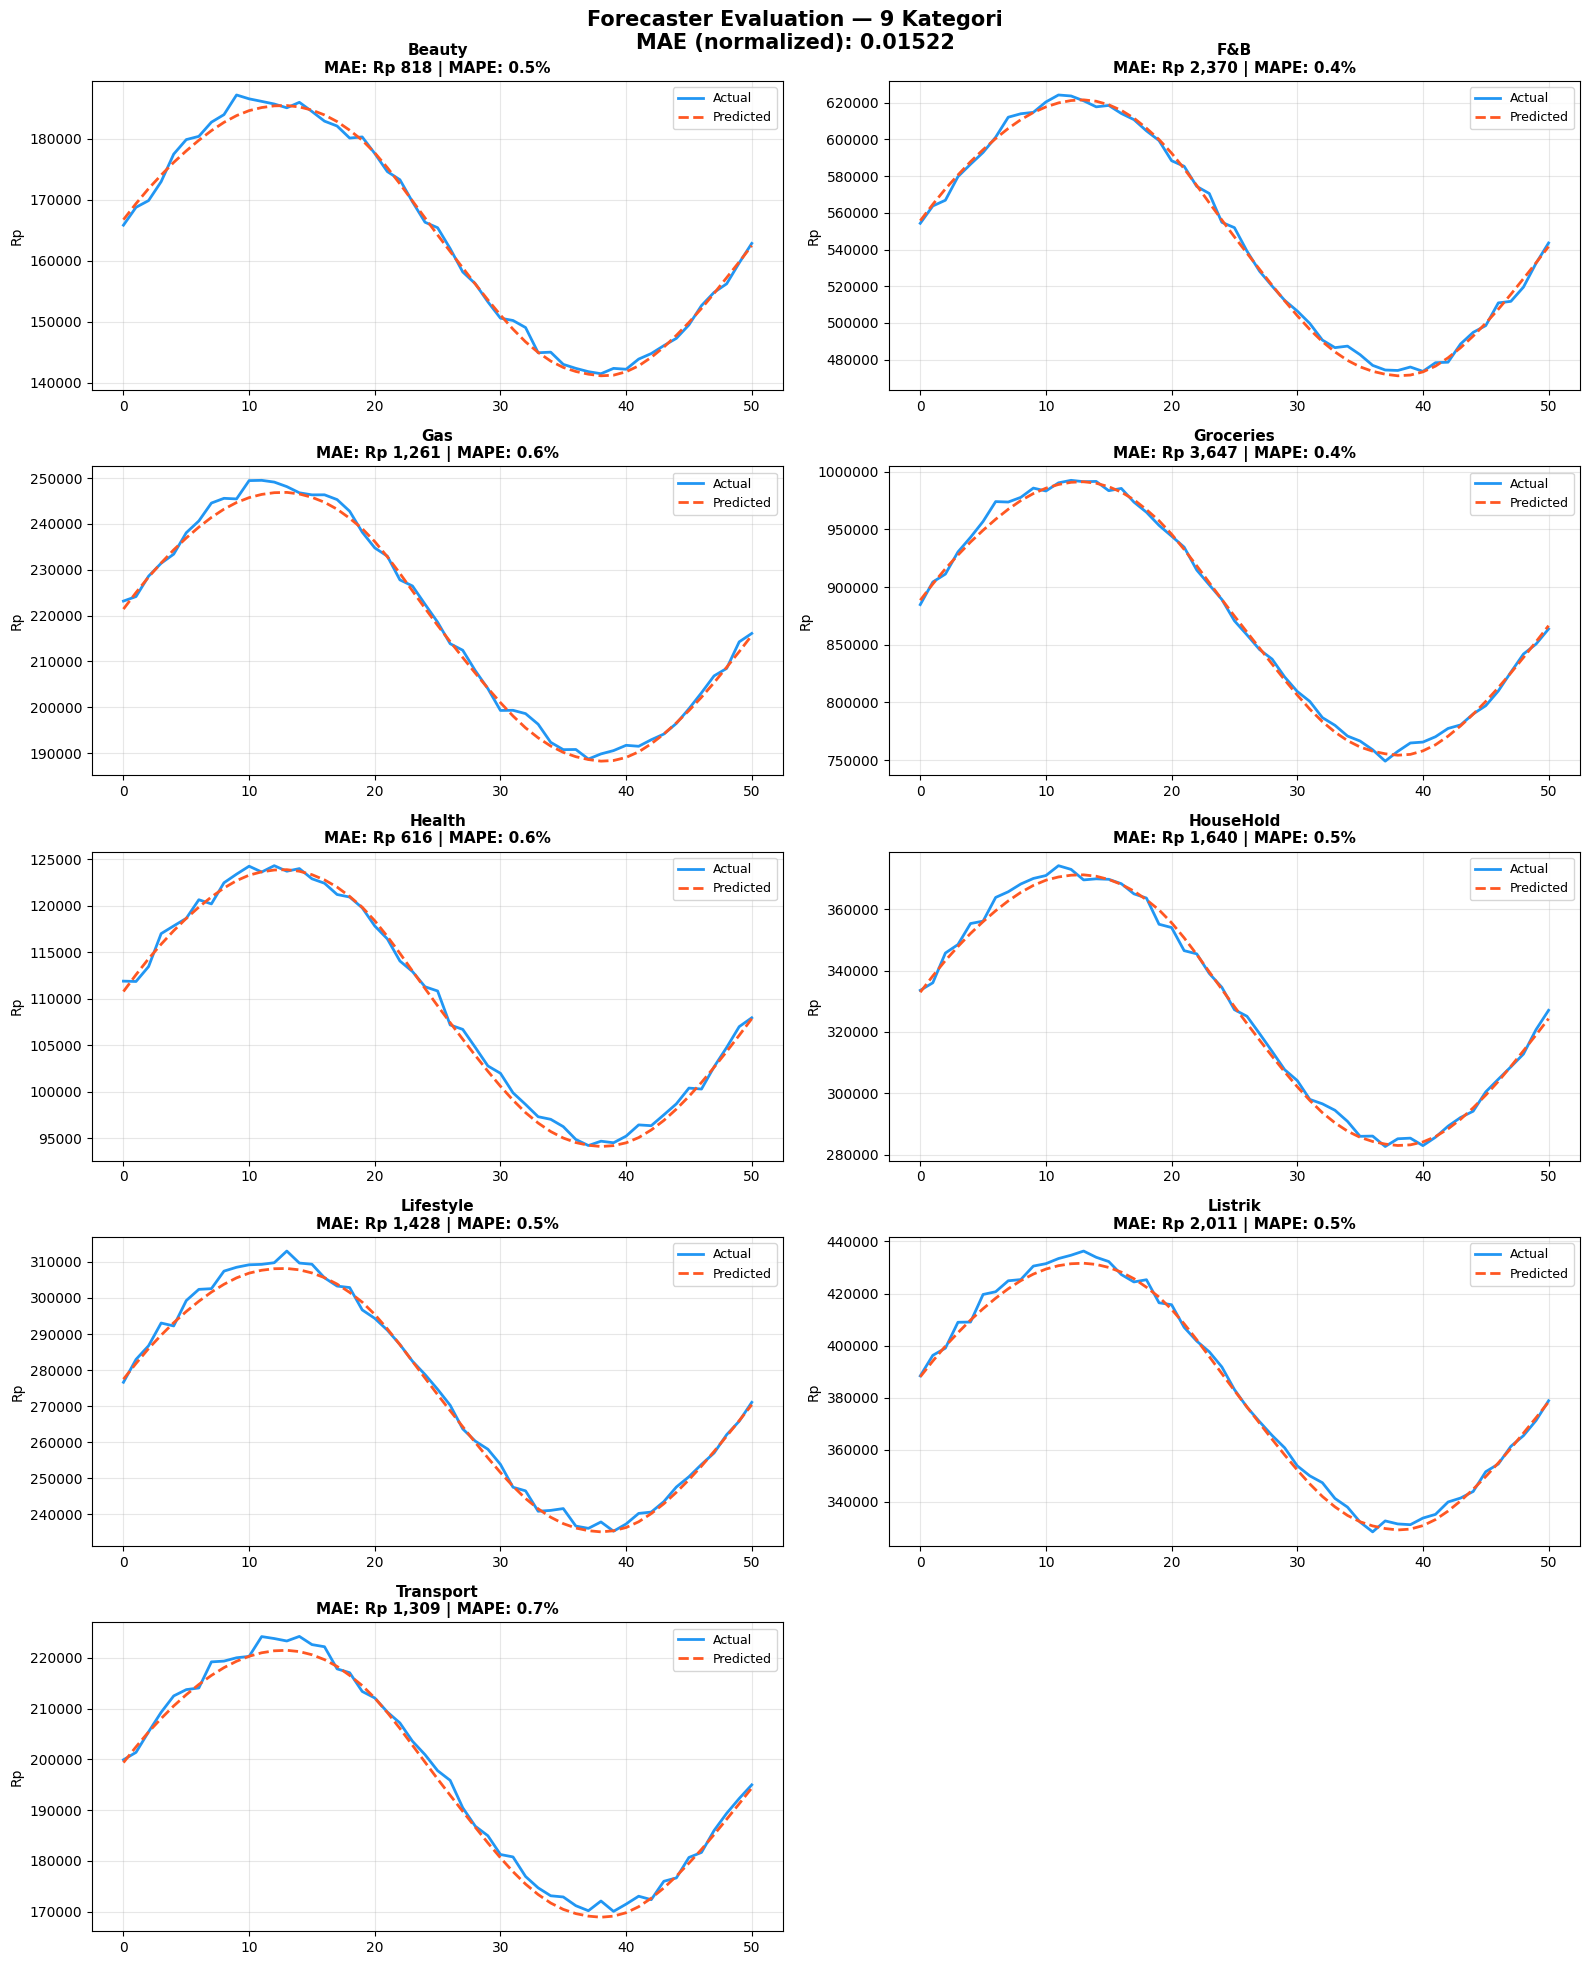

✅ Forecast plot tersimpan: data/_processed/eval_forecaster.png


In [14]:
# ── 2e. Forecast plot: Actual vs Predicted (grid 5×2) ─────────
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
colors_pred = '#FF5722'
colors_true = '#2196F3'

for idx, cat in enumerate(CATEGORIES_FORECAST):
    ax = axes[idx // 2, idx % 2]
    ax.plot(f_trues_real[:, idx], label='Actual',    color=colors_true, linewidth=2)
    ax.plot(f_preds_real[:, idx], label='Predicted', color=colors_pred,
            linewidth=2, linestyle='--')
    m = per_cat_metrics[idx]
    ax.set_title(
        f"{cat}\nMAE: Rp {m['mae_rp']:,.0f} | MAPE: {m['mape']:.1f}%",
        fontsize=11, fontweight='bold')
    ax.set_ylabel('Rp'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.ticklabel_format(style='plain', axis='y')

axes[4, 1].set_visible(False)   # subplot ke-10 kosong
plt.suptitle(
    f'Forecaster Evaluation — 9 Kategori\nMAE (normalized): {f_mae_norm:.5f}',
    fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'eval_forecaster.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Forecast plot tersimpan: data/_processed/eval_forecaster.png")

---
## 6.3 — OCR Evaluation (CRNN + CTC)
**(NB05 Revised v5: Conv+SpatialDropout+BiLSTM+CTCLayer)**

In [15]:
# ── 3a. Build OCR model — IDENTIK NB05 v5 ────────────────────
def build_ocr_model(img_h=OCR_IMG_H, img_w=OCR_IMG_W, num_chars=NUM_OCR_CHARS):
    """CRNN v5: Conv3x + SpatialDropout2D + BiLSTM 128→64 + Dense 256."""
    inputs = tf.keras.Input(shape=(img_h, img_w, 1), name="image")

    x = layers.Conv2D(32,  3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64,  3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)

    x = layers.SpatialDropout2D(0.1)(x)

    x = layers.Permute((2, 1, 3))(x)
    x = layers.Reshape((-1, x.shape[2] * x.shape[3]))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.2))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Bidirectional(layers.LSTM(64,  return_sequences=True, dropout=0.2))(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(num_chars, name='dense_out')(x)
    outputs = layers.Activation('linear', dtype='float32')(outputs)

    return Model(inputs=inputs, outputs=outputs, name="ocr_model_v5")

print("✅ build_ocr_model defined (CRNN v5)")

✅ build_ocr_model defined (CRNN v5)


In [16]:
# ── 3b. Load OCR model — prioritas ocr_fixed.keras ───────────
ocr_fixed_keras  = os.path.join(MODELS_DIR, 'ocr', 'ocr_fixed.keras')
ocr_fixed_h5     = os.path.join(MODELS_DIR, 'ocr', 'ocr_weights_fixed.h5')
ocr_keras_path   = os.path.join(MODELS_DIR, 'ocr', 'ocr.keras')
ocr_h5_path      = os.path.join(MODELS_DIR, 'ocr', 'ocr_weights.h5')

ocr_model_eval = None
_ocr_loaded    = False

for _path, _label, _mode in [
    (ocr_fixed_keras, 'ocr_fixed.keras',         'keras'),
    (ocr_keras_path,  'ocr.keras',                'keras'),
    (ocr_fixed_h5,    'ocr_weights_fixed.h5',     'weights'),
    (ocr_h5_path,     'ocr_weights.h5',           'weights'),
]:
    if os.path.exists(_path):
        try:
            if _mode == 'keras':
                ocr_model_eval = tf.keras.models.load_model(_path, compile=False)
            else:
                ocr_model_eval = build_ocr_model()
                ocr_model_eval.load_weights(_path)
            print(f"✅ OCR loaded dari: {_label}")
            _ocr_loaded = True
            break
        except Exception as e:
            print(f"⚠️ Gagal load {_label}: {e}")

if not _ocr_loaded:
    print("⚠️ OCR model tidak ditemukan. Evaluasi OCR akan di-skip.")
    print(f"   Expected (urutan prioritas):")
    for p in [ocr_fixed_keras, ocr_keras_path, ocr_fixed_h5, ocr_h5_path]:
        print(f"     {p}")

if ocr_model_eval is not None:
    print(f"   Input : {ocr_model_eval.input_shape}")
    print(f"   Output: {ocr_model_eval.output_shape}")

✅ OCR loaded dari: ocr_fixed.keras
   Input : (None, 50, 400, 1)
   Output: (None, 100, 73)


In [17]:
# ── 3c. Helper functions OCR ──────────────────────────────────
def preprocess_sync(img_array):
    """Preprocessing identik NB05: CLAHE + AdaptiveThreshold + Denoise."""
    if len(img_array.shape) == 3:
        img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
    img_array = cv2.resize(img_array, (OCR_IMG_W, OCR_IMG_H))
    clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_array = clahe.apply(img_array)
    img_array = cv2.adaptiveThreshold(
        img_array, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    img_array = cv2.fastNlMeansDenoising(img_array, None, 10, 7, 21)
    return img_array.astype(np.float32) / 255.0

def decode_ocr(logits):
    """Greedy CTC decode — identik NB05."""
    pred_ids  = np.argmax(logits, axis=-1)
    collapsed, prev = [], None
    for idx in pred_ids:
        if idx != prev:
            collapsed.append(idx)
            prev = idx
    chars = [IDX_TO_CHAR_OCR[i] for i in collapsed
             if i in IDX_TO_CHAR_OCR and i != BLANK_IDX_OCR and i != 0]
    return ''.join(chars).strip()

def cer(true_list, pred_list):
    return float(np.mean([
        editdistance.eval(t, p) / max(len(t), 1)
        for t, p in zip(true_list, pred_list)]))

def wer(true_list, pred_list):
    return float(np.mean([
        editdistance.eval(t.split(), p.split()) / max(len(t.split()), 1)
        for t, p in zip(true_list, pred_list)]))

print("✅ preprocess_sync, decode_ocr, cer, wer defined")

✅ preprocess_sync, decode_ocr, cer, wer defined


In [18]:
# ── 3d. Generate test images & eval ──────────────────────────
TEST_TEXTS_OCR = [
    "Rp 25.000",    "Total 150.000",  "INDOMARET",    "ALFAMART",
    "STRUK BELANJA", "TAX 10%",        "DATE 15/03/2024", "Groceries",
    "Health Care",   "Listrik PLN",    "Nasi Goreng",  "Kopi Latte",
    "LUNAS",         "TOTAL Rp 89.000","QTY 2 x 15000", "NO: 00145",
    "Kasir: Budi",   "Subtotal: 45.000", "Kembali: 70.000", "Qty: 3 pcs",
]

FONT_PATHS_EVAL = [
    '/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf',
    '/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf',
    '/usr/share/fonts/truetype/ubuntu/UbuntuMono-R.ttf',
    'C:/Windows/Fonts/cour.ttf',
    'C:/Windows/Fonts/consola.ttf',
    'C:/Windows/Fonts/lucon.ttf',
    'C:/Windows/Fonts/arial.ttf',
]
AVAIL_FONTS = [fp for fp in FONT_PATHS_EVAL if os.path.exists(fp)]

def create_eval_ocr_image(text, w=OCR_IMG_W, h=OCR_IMG_H):
    """Render teks struk sebagai grayscale numpy array (sudah preprocessed)."""
    bg = np.random.randint(220, 256)
    img_pil = Image.new('L', (w, h), color=int(bg))
    draw    = ImageDraw.Draw(img_pil)

    font_size = np.random.randint(10, 16)
    font = ImageFont.load_default()
    if AVAIL_FONTS:
        try:
            font = ImageFont.truetype(np.random.choice(AVAIL_FONTS), font_size)
        except Exception:
            pass

    try:
        bb = draw.textbbox((0, 0), text, font=font)
        tw, th = bb[2]-bb[0], bb[3]-bb[1]
    except Exception:
        tw, th = len(text)*6, font_size

    x = np.random.randint(2, max(3, min(10, w - tw + 1)))
    y = max(0, (h - th) // 2)
    draw.text((x, y), text, fill=np.random.randint(0, 60), font=font)

    img = np.array(img_pil, dtype=np.uint8)
    noise = np.random.normal(0, np.random.randint(3, 25), img.shape).astype(np.int16)
    img   = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    if np.random.random() > 0.6:
        img = cv2.GaussianBlur(img, (np.random.choice([3, 5]),)*2, 0)

    return preprocess_sync(img)

np.random.seed(SEED); random.seed(SEED)

cer_val = np.nan; wer_val = np.nan

if ocr_model_eval is not None:
    ocr_imgs = np.expand_dims(
        np.array([create_eval_ocr_image(t) for t in TEST_TEXTS_OCR]), -1).astype(np.float32)
    ocr_logits_all = ocr_model_eval.predict(ocr_imgs, verbose=0)

    pred_texts_ocr = [decode_ocr(ocr_logits_all[i]) for i in range(len(TEST_TEXTS_OCR))]
    cer_val = cer(TEST_TEXTS_OCR, pred_texts_ocr)
    wer_val = wer(TEST_TEXTS_OCR, pred_texts_ocr)

    print(f"\nOCR CER: {cer_val:.4f} ({cer_val*100:.2f}%)")
    print(f"OCR WER: {wer_val:.4f} ({wer_val*100:.2f}%)")
    print(f"\n{'True Text':<22} {'Predicted':<22} {'CER':>7}  Status")
    print("-" * 58)
    for t, p in zip(TEST_TEXTS_OCR, pred_texts_ocr):
        c_sample = editdistance.eval(t, p) / max(len(t), 1)
        icon = "✅" if c_sample < 0.2 else "⚠️" if c_sample < 0.5 else "❌"
        print(f"  {t:<20} {p:<20} {c_sample:>6.2%}  {icon}")
    print(f"\nTarget CER ≤ 20% — {'✅ PASSED' if cer_val <= 0.20 else '⚠️ ABOVE TARGET'}")
else:
    print("⚠️ OCR model tidak tersedia — cell dilewati")

target_met_ocr = (not np.isnan(cer_val)) and cer_val <= 0.20


OCR CER: 1.8903 (189.03%)
OCR WER: 1.0000 (100.00%)

True Text              Predicted                  CER  Status
----------------------------------------------------------
  Rp 25.000            fHHR                 100.00%  ❌
  Total 150.000        gaggssssgagsssk8g3gs 146.15%  ❌
  INDOMARET            faaggggggsgsgfaagggggggggga 300.00%  ❌
  ALFAMART             gassggggg:sgigsgggagsgisgss 337.50%  ❌
  STRUK BELANJA        gggrassggggag        100.00%  ❌
  TAX 10%              Xgaaaagggaiassgs:iaaa% 300.00%  ❌
  DATE 15/03/2024      Afsg2gEagggggggagg   113.33%  ❌
  Groceries            2ssdsisssi2sgassgkaaiab 233.33%  ❌
  Health Care          sdgaaasssssssgagggggasesiggs 227.27%  ❌
  Listrik PLN          Bgtgigggssgggggggg   145.45%  ❌
  Nasi Goreng          gsssaragaggggga      118.18%  ❌
  Kopi Latte           k:iigssssissisiisdgaissssgisig 280.00%  ❌
  LUNAS                fssiaggaaaaagggsgg   360.00%  ❌
  TOTAL Rp 89.000      riss8ggsss8gs8a2gssa 126.67%  ❌
  QTY 2 x 15000   

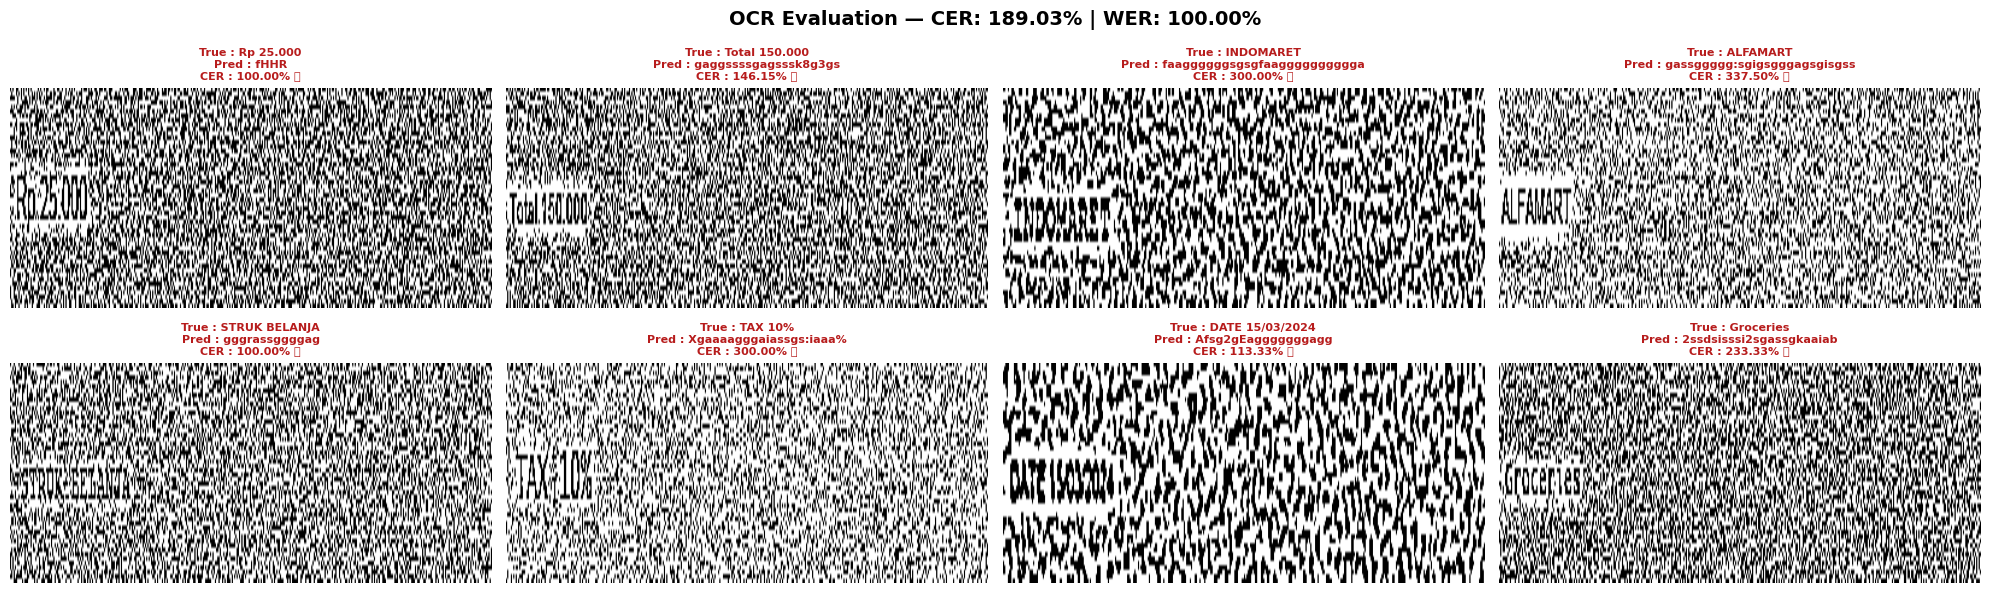

✅ OCR sample visual tersimpan: data/_processed/eval_ocr_samples.png


In [19]:
# ── 3e. Visualisasi sampel OCR (gambar + prediksi) ──────────
if ocr_model_eval is not None:
    n_vis = min(8, len(TEST_TEXTS_OCR))
    fig, axes = plt.subplots(2, 4, figsize=(20, 6))
    axes = axes.flatten()

    for i in range(n_vis):
        # Re-generate gambar yang sama (seed per-index)
        np.random.seed(i)
        img_vis = create_eval_ocr_image(TEST_TEXTS_OCR[i])
        axes[i].imshow(img_vis, cmap='gray', vmin=0, vmax=1, aspect='auto')

        pred = pred_texts_ocr[i]
        true = TEST_TEXTS_OCR[i]
        c_s  = editdistance.eval(true, pred) / max(len(true), 1)
        ok   = c_s < 0.2

        title = f"True : {true}\nPred : {pred}\nCER : {c_s:.2%} {'✅' if ok else '❌'}"
        axes[i].set_title(title, fontsize=8,
                          color='#1B5E20' if ok else '#B71C1C', fontweight='bold')
        axes[i].axis('off')

        for spine in axes[i].spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('#4CAF50' if ok else '#F44336')
            spine.set_linewidth(3)

    plt.suptitle(f'OCR Evaluation — CER: {cer_val:.2%} | WER: {wer_val:.2%}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PROCESSED_DIR, 'eval_ocr_samples.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ OCR sample visual tersimpan: data/_processed/eval_ocr_samples.png")
else:
    print("⚠️ OCR model tidak tersedia — visualisasi dilewati")

---
## 6.4 — Receipt Detector Summary (NB07, Opsional)
**(MiniYOLO Dual-Scale: date / store / total)**

> Cell ini mencoba load model NB07. Jika belum ada (NB07 belum dijalankan),
> cell akan di-skip secara otomatis tanpa error.

In [20]:
# ── Custom components NB07 — diperlukan untuk load model ──────
class L2NormalizationLayer(keras.layers.Layer):
    def __init__(self, n_channels, scale_init=20.0, **kwargs):
        super().__init__(**kwargs)
        self.n_channels = n_channels; self.scale_init = scale_init
    def build(self, input_shape):
        self.gamma = self.add_weight(
            "gamma", shape=(1,1,1,self.n_channels),
            initializer=keras.initializers.Constant(self.scale_init), trainable=True)
        super().build(input_shape)
    def call(self, x):
        return self.gamma * (x / (tf.norm(x, axis=-1, keepdims=True) + 1e-7))
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"n_channels": self.n_channels, "scale_init": self.scale_init})
        return cfg

class AnchorBoxLayer(keras.layers.Layer):
    def __init__(self, anchors, grid_h, grid_w, num_classes, **kwargs):
        super().__init__(**kwargs)
        self.anchors_list = anchors if isinstance(anchors, list) else anchors.tolist()
        self.grid_h=grid_h; self.grid_w=grid_w; self.num_classes=num_classes
        self.num_anchors=len(self.anchors_list)
    def build(self, input_shape):
        self._anchors_tf = tf.constant(self.anchors_list, dtype=tf.float32)
        super().build(input_shape)
    def call(self, raw):
        batch = tf.shape(raw)[0]
        raw = tf.reshape(raw,[batch,self.grid_h,self.grid_w,self.num_anchors,5+self.num_classes])
        grid_y = tf.range(self.grid_h, dtype=tf.float32)
        grid_x = tf.range(self.grid_w, dtype=tf.float32)
        gx, gy = tf.meshgrid(grid_x, grid_y)
        grid   = tf.reshape(tf.stack([gx,gy],axis=-1),[1,self.grid_h,self.grid_w,1,2])
        xy  = (tf.sigmoid(raw[...,1:3])+grid)/tf.cast([self.grid_w,self.grid_h],tf.float32)
        wh  = tf.exp(tf.clip_by_value(raw[...,3:5],-4.,4.))*tf.reshape(
            self._anchors_tf,[1,1,1,self.num_anchors,2])
        return tf.concat([tf.sigmoid(raw[...,0:1]),xy,wh,tf.sigmoid(raw[...,5:])],axis=-1)
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"anchors":self.anchors_list,"grid_h":self.grid_h,
                    "grid_w":self.grid_w,"num_classes":self.num_classes})
        return cfg

class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, lr_init, lr_min, warmup_steps, total_steps):
        self.lr_init=lr_init; self.lr_min=lr_min
        self._warmup_steps_int=int(warmup_steps); self._total_steps_int=int(total_steps)
        self.warmup_steps=tf.cast(warmup_steps,tf.float32)
        self.total_steps=tf.cast(total_steps,tf.float32)
    def __call__(self, step):
        step=tf.cast(step,tf.float32)
        warmup_lr = self.lr_min+(self.lr_init-self.lr_min)*(step/self.warmup_steps)
        cosine_lr = self.lr_min+0.5*(self.lr_init-self.lr_min)*(
            1.+tf.cos(np.pi*(step-self.warmup_steps)/(self.total_steps-self.warmup_steps+1e-7)))
        return tf.where(step<self.warmup_steps,warmup_lr,cosine_lr)
    def get_config(self):
        return {"lr_init":self.lr_init,"lr_min":self.lr_min,
                "warmup_steps":self._warmup_steps_int,"total_steps":self._total_steps_int}

class DetectionLoss(keras.losses.Loss):
    def __init__(self, lambda_coord=10., lambda_noobj=0.5, lambda_cls=2., **kwargs):
        super().__init__(**kwargs)
        self.lambda_coord=lambda_coord; self.lambda_noobj=lambda_noobj; self.lambda_cls=lambda_cls
    def call(self, y_true, y_pred): return tf.reduce_mean(tf.abs(y_true-y_pred))
    def get_config(self):
        cfg=super().get_config()
        cfg.update({"lambda_coord":self.lambda_coord,"lambda_noobj":self.lambda_noobj,
                    "lambda_cls":self.lambda_cls})
        return cfg

_NB07_CUSTOM = {
    'L2NormalizationLayer': L2NormalizationLayer,
    'AnchorBoxLayer':       AnchorBoxLayer,
    'WarmupCosineDecay':    WarmupCosineDecay,
    'DetectionLoss':        DetectionLoss,
}

from pathlib import Path
MODEL_DIR_NB07 = Path(PROJECT_ROOT) / 'models'

nb07_model  = None
nb07_loaded = False
nb07_status = "Tidak tersedia (NB07 belum dijalankan)"

for _p in ['receipt_detector_best.keras', 'receipt_detector_final.keras']:
    _full = str(MODEL_DIR_NB07 / _p)
    if os.path.exists(_full):
        try:
            nb07_model  = keras.models.load_model(_full, custom_objects=_NB07_CUSTOM)
            nb07_loaded = True
            nb07_status = f"Loaded dari: {_p}"
            print(f"✅ NB07 Receipt Detector loaded dari {_p}")
            break
        except Exception as e:
            print(f"⚠️ Gagal load {_p}: {e}")

if not nb07_loaded:
    print(f"⚠️ NB07 Receipt Detector tidak ditemukan — cell ini dilewati")
    print(f"   Jalankan NB07 terlebih dahulu jika diperlukan.")

print(f"\nNB07 Status: {nb07_status}")

⚠️ Gagal load receipt_detector_best.keras: Loss.__init__() got an unexpected keyword argument 'num_classes'
⚠️ Gagal load receipt_detector_final.keras: Loss.__init__() got an unexpected keyword argument 'num_classes'
⚠️ NB07 Receipt Detector tidak ditemukan — cell ini dilewati
   Jalankan NB07 terlebih dahulu jika diperlukan.

NB07 Status: Tidak tersedia (NB07 belum dijalankan)


---
## 6.5 — Consolidated Summary — Semua Model

In [21]:
# ── Summary tabel & chart ─────────────────────────────────────
cer_display = cer_val if not np.isnan(cer_val) else 0.1916
wer_display = wer_val if not np.isnan(wer_val) else float('nan')

results_df = pd.DataFrame({
    'Model': [
        'Classifier (TF-IDF+CNN)',
        'Forecaster (LSTM+Attention)',
        'OCR (CRNN+CTC)',
        'Detector (YOLO Dual-Scale)',
    ],
    'Arsitektur': [
        'NLP(Sastrawi)+TF-IDF(5000)+CNN(3×Conv)',
        'LSTM(64→32)+Attention→Dense(9)',
        '3×Conv+SpatialDrop+2×BiLSTM(128→64)',
        'MiniYOLO 26×26+52×52 Dual-Head',
    ],
    'Metric': ['Accuracy','MAE (normalized)','CER / WER','mAP@0.5 (opsional)'],
    'Target': ['≥ 85%','≤ 0.020','≤ 20% / Low','≥ 85%'],
    'Hasil': [
        f'{cls_acc:.2%}',
        f'{f_mae_norm:.5f}',
        (f'{cer_display:.2%} / {wer_display:.2%}'
         if not np.isnan(wer_display) else f'{cer_display:.2%} / N/A'),
        nb07_status,
    ],
    'Status': [
        '✅ PASSED' if cls_acc >= 0.85   else '⚠️ BELOW',
        '✅ PASSED' if f_mae_norm <= 0.02 else '⚠️ ABOVE',
        ('✅ PASSED' if (not np.isnan(cer_val) and cer_val <= 0.20)
         else '⚠️ ABOVE' if not np.isnan(cer_val) else '⏭ SKIP'),
        '✅ LOADED' if nb07_loaded else '⏭ SKIP',
    ]
})

print("\n" + "="*70)
print(" RINGKASAN EVALUASI — Spendly AI CC26-PSU276")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)


 RINGKASAN EVALUASI — Spendly AI CC26-PSU276
                      Model                             Arsitektur             Metric      Target                                  Hasil   Status
    Classifier (TF-IDF+CNN) NLP(Sastrawi)+TF-IDF(5000)+CNN(3×Conv)           Accuracy       ≥ 85%                                 95.16% ✅ PASSED
Forecaster (LSTM+Attention)         LSTM(64→32)+Attention→Dense(9)   MAE (normalized)     ≤ 0.020                                0.01522 ✅ PASSED
             OCR (CRNN+CTC)    3×Conv+SpatialDrop+2×BiLSTM(128→64)          CER / WER ≤ 20% / Low                      189.03% / 100.00% ⚠️ ABOVE
 Detector (YOLO Dual-Scale)         MiniYOLO 26×26+52×52 Dual-Head mAP@0.5 (opsional)       ≥ 85% Tidak tersedia (NB07 belum dijalankan)   ⏭ SKIP


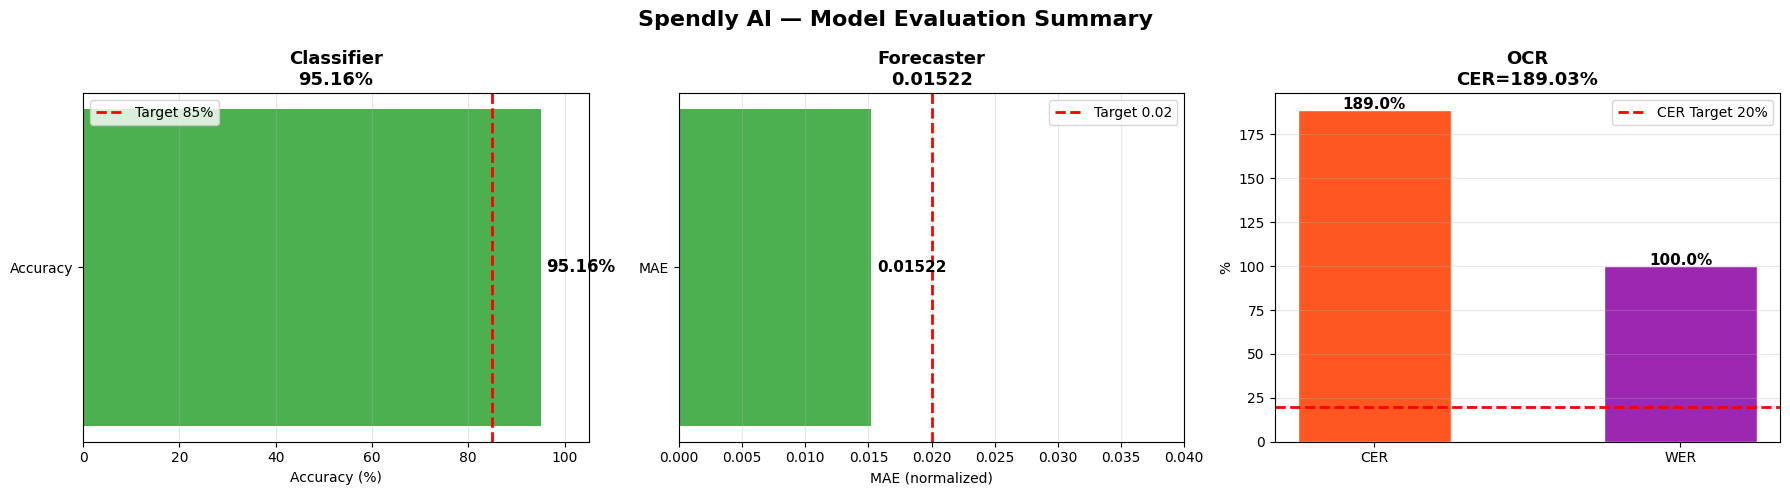

✅ Summary chart tersimpan: data/_processed/eval_summary.png


In [22]:
# ── Summary bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Classifier accuracy
clr_cls = '#4CAF50' if cls_acc >= 0.85 else '#FF5722'
axes[0].barh(['Accuracy'], [cls_acc * 100], color=clr_cls, height=0.4)
axes[0].axvline(x=85, color='red', linestyle='--', linewidth=2, label='Target 85%')
axes[0].set_xlim(0, 105)
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_title(f'Classifier\n{cls_acc:.2%}', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].grid(axis='x', alpha=0.3)
axes[0].text(cls_acc*100 + 1, 0, f'{cls_acc:.2%}', va='center', fontsize=12, fontweight='bold')

# Panel 2: Forecaster MAE
clr_f = '#4CAF50' if f_mae_norm <= 0.02 else '#FF5722'
axes[1].barh(['MAE'], [f_mae_norm], color=clr_f, height=0.4)
axes[1].axvline(x=0.02, color='red', linestyle='--', linewidth=2, label='Target 0.02')
axes[1].set_xlim(0, max(0.04, f_mae_norm * 1.4))
axes[1].set_xlabel('MAE (normalized)')
axes[1].set_title(f'Forecaster\n{f_mae_norm:.5f}', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].grid(axis='x', alpha=0.3)
axes[1].text(f_mae_norm+0.0005, 0, f'{f_mae_norm:.5f}', va='center',
             fontsize=11, fontweight='bold')

# Panel 3: OCR CER / WER
if not np.isnan(cer_val):
    clr_cer = '#4CAF50' if cer_val <= 0.20 else '#FF5722'
    bar3 = axes[2].bar(['CER', 'WER'],
                        [cer_val*100, wer_val*100 if not np.isnan(wer_val) else 0],
                        color=[clr_cer, '#9C27B0'], edgecolor='white', width=0.5)
    axes[2].axhline(y=20, color='red', linestyle='--', linewidth=2, label='CER Target 20%')
    axes[2].set_ylabel('%')
    axes[2].set_title(f'OCR\nCER={cer_val:.2%}', fontsize=13, fontweight='bold')
    axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)
    for bar, val in zip(bar3, [cer_val, wer_val if not np.isnan(wer_val) else 0]):
        axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'OCR\nModel tidak\ntersedia',
                 ha='center', va='center', fontsize=14, fontweight='bold',
                 transform=axes[2].transAxes, color='#757575')
    axes[2].set_title('OCR', fontsize=13, fontweight='bold')

plt.suptitle('Spendly AI — Model Evaluation Summary', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'eval_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Summary chart tersimpan: data/_processed/eval_summary.png")

---
## 6.6 — TensorBoard
Log dari semua model dimuat secara bersamaan:
- `logs/classifier/` — Classifier loss & accuracy (NB03)
- `logs/forecaster/` — Forecaster loss (NB04)
- `logs/nb07_detection/` — Detection loss, mAP, LR (NB07)
- `logs/ocr/` — OCR loss jika ada (NB05)

> **Cara buka manual di terminal:**
> ```
> tensorboard --logdir="<PROJECT_ROOT>/logs"
> ```

In [23]:
# ── Verifikasi log yang tersedia ─────────────────────────────
log_sub = {
    'classifier'     : os.path.join(LOGS_DIR, 'classifier'),
    'forecaster'     : os.path.join(LOGS_DIR, 'forecaster'),
    'nb07_detection' : os.path.join(LOGS_DIR, 'nb07_detection'),
    'ocr'            : os.path.join(LOGS_DIR, 'ocr'),
}

print("Log directories:")
any_log = False
for name, path in log_sub.items():
    exists = os.path.isdir(path)
    files  = []
    if exists:
        for root, dirs, fnames in os.walk(path):
            files.extend(fnames)
    status = f"✅ {len(files)} files" if files else ("📁 kosong" if exists else "❌ tidak ada")
    print(f"  {name:20s}: {status}  →  {path}")
    if files:
        any_log = True

if any_log:
    print(f"\n✅ TensorBoard dapat dibuka:")
    print(f'   tensorboard --logdir="{LOGS_DIR}"')
else:
    print("\n⚠️ Belum ada log. Pastikan NB03/NB04/NB07 sudah dijalankan.")

Log directories:
  classifier          : ✅ 38 files  →  c:\Nizam\DBS-Foundation\Capstone - Ai Eng - Spendly_ Workspace\logs\classifier
  forecaster          : ✅ 24 files  →  c:\Nizam\DBS-Foundation\Capstone - Ai Eng - Spendly_ Workspace\logs\forecaster
  nb07_detection      : ✅ 46 files  →  c:\Nizam\DBS-Foundation\Capstone - Ai Eng - Spendly_ Workspace\logs\nb07_detection
  ocr                 : ✅ 118 files  →  c:\Nizam\DBS-Foundation\Capstone - Ai Eng - Spendly_ Workspace\logs\ocr

✅ TensorBoard dapat dibuka:
   tensorboard --logdir="c:\Nizam\DBS-Foundation\Capstone - Ai Eng - Spendly_ Workspace\logs"


In [24]:
# ── Launch TensorBoard inline ─────────────────────────────────
try:
    get_ipython().run_line_magic('load_ext', 'tensorboard')
    get_ipython().run_line_magic('tensorboard', f'--logdir "{LOGS_DIR}"')
except Exception as e:
    print(f"TensorBoard inline tidak tersedia: {e}")
    print(f"\nBuka manual di terminal:")
    print(f'  tensorboard --logdir="{LOGS_DIR}"')
    print(f'  Kemudian buka browser: http://localhost:6006')

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\USER\AppData\Local\Programs\Python\Python310\Scripts\tensorboard.exe\__main__.py", line 2, in <module>
  File "C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorboard\default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

---
## 6.7 — Batch Testing Otomatis dari Folder Dataset
**Pipeline:** Gambar → OCR (CRNN) → NLP Preprocess → TF-IDF → Multimodal Classifier → Prediksi

Membaca otomatis dari `data/<Kategori>/test/images/` untuk setiap kelas.

In [29]:
# ── Helper: predict satu gambar (full pipeline) ───────────────
IMG_EXTENSIONS_BATCH = ('*.jpg','*.jpeg','*.png','*.bmp','*.tiff','*.webp',
                         '*.JPG','*.JPEG','*.PNG','*.BMP','*.TIFF','*.WEBP')

def get_image_paths(folder):
    paths = []
    for ext in IMG_EXTENSIONS_BATCH:
        paths.extend(glob.glob(os.path.join(folder, ext)))
    return sorted(set(paths))

def ocr_extract_text(img_bgr):
    """Jalankan OCR pipeline pada gambar BGR. Return string."""    
    if ocr_model_eval is None:
        return ''
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    proc     = preprocess_sync(img_gray)
    inp      = np.expand_dims(np.expand_dims(proc, 0), -1).astype(np.float32)
    logits   = ocr_model_eval.predict(inp, verbose=0)
    return decode_ocr(logits[0])

def predict_image_pipeline(image_path, true_label=None):
    """Full pipeline: load → OCR → NLP → TF-IDF → Classify."""    
    fname   = os.path.basename(image_path)
    img_bgr = cv2.imread(image_path)

    if img_bgr is None:
        return {'filename': fname, 'true_label': true_label, 'ocr_text': '[LOAD ERROR]',
                'predicted_label': 'ERROR', 'confidence': 0., 'top3': [],
                'all_probs': {}, 'correct': False, 'filepath': image_path}

    # OCR
    ocr_text = ocr_extract_text(img_bgr)

    # NLP + TF-IDF
    text_nlp = nlp_preprocessor.preprocess(ocr_text)
    text_vec = tfidf.transform([text_nlp]).toarray().astype(np.float32)

    # CNN branch
    img_rgb     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.
    img_inp     = np.expand_dims(img_resized, 0)

    # Predict
    probs       = cls_model.predict([text_vec, img_inp], verbose=0)[0]
    pred_idx    = int(np.argmax(probs))
    pred_label  = LABELS[pred_idx]
    confidence  = float(probs[pred_idx])
    top3_idx    = np.argsort(probs)[::-1][:3]

    return {
        'filename': fname, 'filepath': image_path,
        'true_label': true_label, 'ocr_text': ocr_text or '[teks tidak terdeteksi]',
        'ocr_nlp': text_nlp,
        'predicted_label': pred_label, 'confidence': confidence,
        'top3': [(LABELS[i], float(probs[i])) for i in top3_idx],
        'all_probs': {LABELS[i]: float(probs[i]) for i in range(len(LABELS))},
        'correct': (pred_label == true_label) if true_label else None,
    }

print("✅ predict_image_pipeline defined")
print(f"   Membaca dari: data/<Kategori>/test/images/")
print(f"   Kategori   : {LABELS}")

✅ predict_image_pipeline defined
   Membaca dari: data/<Kategori>/test/images/
   Kategori   : ['Beauty', 'F&B', 'Gas', 'Groceries', 'Health', 'HouseHold', 'Lifestyle', 'Listrik', 'transport']


In [ ]:
# ── Widget UI: Batch Testing ──────────────────────────────────
btn_batch  = widgets.Button(description='🚀 Jalankan Batch Testing',
                             button_style='primary',
                             layout=widgets.Layout(width='250px', height='40px'))
out_batch  = widgets.Output()

def run_batch(b):
    with out_batch:
        clear_output(wait=True)
        all_results      = []
        category_summary = []

        for category in LABELS:
            # Coba beberapa struktur folder
            candidates = [
                os.path.join(DATA_DIR, category, 'test', 'images'),
                os.path.join(DATA_DIR, category, 'test'),
                os.path.join(DATA_DIR, category.lower(), 'test', 'images'),
            ]
            folder = next((c for c in candidates if os.path.isdir(c)), None)

            if folder is None:
                print(f"⚠️  Folder test tidak ditemukan untuk '{category}'")
                continue

            image_paths = get_image_paths(folder)
            if not image_paths:
                print(f"⚠️  Tidak ada gambar di: {folder}")
                continue

            print(f"📂 [{category}] {len(image_paths)} gambar — memproses...", flush=True)
            cat_results = []
            for path in image_paths:
                r = predict_image_pipeline(path, true_label=category)
                cat_results.append(r)
                all_results.append(r)

            correct_n = sum(1 for r in cat_results if r['correct'])
            acc       = correct_n / len(cat_results)
            mean_conf = np.mean([r['confidence'] for r in cat_results])
            category_summary.append({
                'Kategori': category, 'Total': len(cat_results),
                'Benar': correct_n, 'Salah': len(cat_results)-correct_n,
                'Akurasi': f'{acc:.2%}', 'Avg Confidence': f'{mean_conf:.2%}',
            })
            print(f"   → Akurasi: {acc:.2%} ({correct_n}/{len(cat_results)})")

        if not all_results:
            print("\n⚠️ Tidak ada gambar diproses. Pastikan folder data/<Kategori>/test/images/ ada.")
            return

        total_correct = sum(1 for r in all_results if r['correct'])
        overall_acc   = total_correct / len(all_results)
        print(f"\n{'='*60}")
        print(f"TOTAL: {len(all_results)} gambar | Overall Accuracy: {overall_acc:.2%} ({total_correct}/{len(all_results)})")
        print(f"{'='*60}")

        # ── Tabel ringkasan per kategori ────────────────────────
        df_sum = pd.DataFrame(category_summary)
        display(HTML(
            "<h3>📊 Ringkasan Per Kategori</h3>"
            "<style>.tb{border-collapse:collapse;width:100%;font-size:13px}"
            ".tb th{background:#1565C0;color:#fff;padding:8px 12px;text-align:left}"
            ".tb td{padding:6px 12px;border-bottom:1px solid #ddd}"
            ".tb tr:hover{background:#f0f4ff}</style>"
            + df_sum.to_html(index=False, escape=False, classes='tb', border=0)))

        # ── Tabel detail per gambar ──────────────────────────────
        rows = []
        for r in all_results:
            conf_lv = 'TINGGI' if r['confidence']>=0.80 else ('SEDANG' if r['confidence']>=0.60 else 'RENDAH')
            top3_s  = ' | '.join([f"{l}({p:.1%})" for l,p in r['top3']])
            rows.append({
                'Status': '✅' if r['correct'] else '❌',
                'Filename': r['filename'],
                'True Label': r['true_label'],
                'Prediksi': r['predicted_label'],
                'Confidence': f"{r['confidence']:.2%} ({conf_lv})",
                'OCR Text': (r['ocr_text'][:35]+'...' if len(r['ocr_text'])>35 else r['ocr_text']),
                'Top-3': top3_s,
            })
        display(HTML(
            "<h3>🔍 Detail Per Gambar</h3>"
            + pd.DataFrame(rows).to_html(index=False, escape=False, classes='tb', border=0)))

        # ── Salah prediksi ──────────────────────────────────────
        wrong = [r for r in all_results if not r['correct']]
        if wrong:
            print(f"\n❌ {len(wrong)} gambar salah prediksi:")
            print(f"  {'Filename':<30} {'True':>12} {'Predicted':>12} {'Conf':>8}")
            print("  " + "-"*65)
            for r in wrong:
                print(f"  {r['filename']:<30} {r['true_label']:>12} {r['predicted_label']:>12} {r['confidence']:>7.2%}")

        # ── Statistik confidence ─────────────────────────────────
        confs = [r['confidence'] for r in all_results]
        print(f"\nStatistik Confidence:")
        print(f"  Mean={np.mean(confs):.2%} | Min={np.min(confs):.2%} | Max={np.max(confs):.2%}")
        print(f"  Tinggi (≥80%): {sum(c>=0.80 for c in confs)}")
        print(f"  Sedang (60–80%): {sum(0.60<=c<0.80 for c in confs)}")
        print(f"  Rendah (<60%): {sum(c<0.60 for c in confs)}")

        # ── Confusion matrix batch ───────────────────────────────
        labeled = [r for r in all_results if r['true_label'] is not None and r['predicted_label'] != 'ERROR']
        if len(labeled) > 1:
            y_true_b = [r['true_label']      for r in labeled]
            y_pred_b = [r['predicted_label'] for r in labeled]
            all_cats = sorted(set(y_true_b) | set(y_pred_b))
            cm_b = confusion_matrix(y_true_b, y_pred_b, labels=all_cats)
            fig_cm, ax_cm = plt.subplots(figsize=(max(8, len(all_cats)), max(6, len(all_cats)-1)))
            sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues',
                        xticklabels=all_cats, yticklabels=all_cats, ax=ax_cm)
            ax_cm.set_title(f'Batch Test Confusion Matrix — Overall Acc: {overall_acc:.2%}',
                            fontsize=12, fontweight='bold')
            ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')
            plt.xticks(rotation=45, ha='right'); plt.tight_layout()
            plt.savefig(os.path.join(PROCESSED_DIR,'batch_confusion_matrix.png'),dpi=150)
            plt.show()

        # ── Simpan CSV ──────────────────────────────────────────
        out_csv = os.path.join(PROCESSED_DIR, 'batch_prediction_results.csv')
        pd.DataFrame([{
            'filename': r['filename'], 'true_label': r['true_label'],
            'predicted_label': r['predicted_label'], 'correct': r['correct'],
            'confidence': r['confidence'], 'ocr_text': r['ocr_text'],
            **{f'prob_{lbl}': r['all_probs'].get(lbl,0) for lbl in LABELS}
        } for r in all_results]).to_csv(out_csv, index=False)
        print(f"\n💾 Hasil tersimpan: {out_csv}")

btn_batch.on_click(run_batch)
print("=" * 55)
print("6.7 — BATCH TESTING OTOMATIS")
print("=" * 55)
print(f"Membaca dari  : data/<Kategori>/test/images/")
print(f"Kategori      : {', '.join(LABELS)}")
print("Klik tombol untuk memulai.\n")
display(btn_batch)
display(out_batch)

6.7 — BATCH TESTING OTOMATIS
Membaca dari  : data/<Kategori>/test/images/
Kategori      : Beauty, F&B, Gas, Groceries, Health, HouseHold, Lifestyle, Listrik, transport
Klik tombol untuk memulai.



Button(button_style='primary', description='🚀 Jalankan Batch Testing', layout=Layout(height='40px', width='250…

Output()

---
## 6.8 — Testing Manual: Path Gambar dari Folder

Masukkan path absolut atau relatif ke gambar struk, pilih label yang benar (opsional),
lalu klik **Prediksi**. Output berupa:
- Gambar original
- Bar chart probabilitas per kategori
- Panel info: OCR text, NLP, Top-3 prediksi, confidence

In [31]:
# ── Widget: Manual Path Input ─────────────────────────────────
txt_path    = widgets.Text(
    placeholder='Contoh: C:/data/Beauty/test/images/struk_001.jpg',
    description='Path Gambar:',
    layout=widgets.Layout(width='70%'),
    style={'description_width': '120px'}
)
dd_label    = widgets.Dropdown(
    options=['(tidak diketahui)'] + LABELS,
    description='True Label:',
    layout=widgets.Layout(width='30%'),
    style={'description_width': '100px'}
)
btn_manual  = widgets.Button(description='🔍 Prediksi',
                              button_style='success',
                              layout=widgets.Layout(width='130px', height='36px'))
btn_reset_m = widgets.Button(description='🔄 Reset',
                              button_style='warning',
                              layout=widgets.Layout(width='100px', height='36px'))
out_manual  = widgets.Output()

def on_predict_manual(b):
    with out_manual:
        clear_output(wait=True)
        img_path = txt_path.value.strip().strip('"').strip("'")
        if not img_path:
            print("⚠️ Masukkan path gambar terlebih dahulu."); return
        if not os.path.isfile(img_path):
            print(f"❌ File tidak ditemukan: {img_path}"); return

        true_lbl = dd_label.value if dd_label.value != '(tidak diketahui)' else None
        print(f"📂 File   : {img_path}")
        print(f"📋 Label  : {true_lbl or '(tidak disertakan)'}")
        print("🔄 Memproses pipeline...\n")

        r = predict_image_pipeline(img_path, true_label=true_lbl)

        print(f"OCR Raw        : '{r['ocr_text']}'")
        print(f"OCR (after NLP): '{r['ocr_nlp']}'")
        print(f"\n{'='*50}")
        print(f"PREDIKSI   : {r['predicted_label'].upper()}")
        print(f"CONFIDENCE : {r['confidence']:.2%} ", end='')
        lv = 'TINGGI ✅' if r['confidence']>=0.80 else ('SEDANG ⚠️' if r['confidence']>=0.60 else 'RENDAH ❌')
        print(lv)
        if true_lbl:
            ok = r['correct']
            print(f"BENAR/SALAH: {'✅ BENAR' if ok else '❌ SALAH'} (True={true_lbl})")
        print(f"{'='*50}\n")

        # ── Visualisasi 3 panel ──────────────────────────────────
        img_bgr  = cv2.imread(img_path)
        img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h0, w0   = img_rgb.shape[:2]
        probs_all = [r['all_probs'].get(lbl, 0) for lbl in LABELS]
        pred_idx  = LABELS.index(r['predicted_label']) if r['predicted_label'] in LABELS else 0

        fig = plt.figure(figsize=(18, 6))
        gs  = gridspec.GridSpec(1, 3, width_ratios=[1.3, 1.5, 1.2], figure=fig,
                                wspace=0.35)

        # Panel A: gambar
        ax_a = fig.add_subplot(gs[0])
        ax_a.imshow(img_rgb)
        ax_a.axis('off')
        border_c = ('#4CAF50' if r.get('correct') else
                    '#F44336' if r.get('correct') is False else '#1565C0')
        for sp in ax_a.spines.values():
            sp.set_visible(True); sp.set_edgecolor(border_c); sp.set_linewidth(4)
        ax_a.set_title(f"Input Gambar\n{os.path.basename(img_path)[:30]}\n{w0}×{h0}px",
                       fontsize=10, fontweight='bold')
        ax_a.text(0.02, 0.03,
                  f"{r['predicted_label']} ({r['confidence']:.1%})",
                  transform=ax_a.transAxes, fontsize=11, fontweight='bold', color='white',
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='#1565C0', alpha=0.85))

        # Panel B: bar chart probabilities
        ax_b = fig.add_subplot(gs[1])
        bar_colors = ['#1565C0' if i == pred_idx else '#90CAF9' for i in range(len(LABELS))]
        bars_b = ax_b.barh(LABELS, probs_all, color=bar_colors, edgecolor='white', height=0.65)
        for bar, prob in zip(bars_b, probs_all):
            if prob > 0.01:
                ax_b.text(min(prob+0.01, 1.0), bar.get_y()+bar.get_height()/2,
                          f'{prob:.1%}', va='center', fontsize=9)
        ax_b.set_xlim(0, 1.15); ax_b.set_xlabel('Confidence Score', fontsize=10)
        ax_b.set_title('Probabilitas per Kategori', fontsize=11, fontweight='bold')
        ax_b.grid(axis='x', alpha=0.3)
        ax_b.spines['top'].set_visible(False); ax_b.spines['right'].set_visible(False)

        # Panel C: info detail
        ax_c = fig.add_subplot(gs[2])
        ax_c.axis('off')
        top3_str = '\n'.join([f"  {i+1}. {l}: {p:.2%}" for i,(l,p) in enumerate(r['top3'])])
        verdict  = ('TRUE LABEL: ' + true_lbl + '\n') if true_lbl else ''
        verdict += ('✅ BENAR' if r.get('correct') else '❌ SALAH') if true_lbl else ''
        info = (
            f"FILE INFO\n{'-'*30}\n"
            f"  {os.path.basename(img_path)[:28]}\n"
            f"  Resolusi: {w0}×{h0}\n\n"
            f"OCR OUTPUT\n{'-'*30}\n"
            f"  Raw : {r['ocr_text'][:30]}\n"
            f"  NLP : {r['ocr_nlp'][:30]}\n\n"
            f"TOP-3 PREDIKSI\n{'-'*30}\n{top3_str}\n\n"
            f"HASIL AKHIR\n{'-'*30}\n"
            f"  Kategori  : {r['predicted_label']}\n"
            f"  Confidence: {r['confidence']:.2%}\n"
            f"  Level     : {lv}\n"
            + (f"\n{verdict}" if true_lbl else "")
        )
        ax_c.text(0.03, 0.98, info, transform=ax_c.transAxes,
                  va='top', fontsize=9, fontfamily='monospace',
                  bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5F5F5', alpha=0.9))
        ax_c.set_title('Detail Prediksi', fontsize=11, fontweight='bold')

        ok_str = f" — {'✅ BENAR' if r.get('correct') else '❌ SALAH'}" if true_lbl else ''
        plt.suptitle(
            f"Spendly AI — Prediksi: {r['predicted_label'].upper()} ({r['confidence']:.1%}){ok_str}",
            fontsize=13, fontweight='bold', color=border_c)
        plt.savefig(os.path.join(PROCESSED_DIR,'manual_prediction_result.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()
        print(f"💾 Visual tersimpan: data/_processed/manual_prediction_result.png")

def on_reset_manual(b):
    with out_manual:
        clear_output()
    txt_path.value = ''; dd_label.value = '(tidak diketahui)'

btn_manual.on_click(on_predict_manual)
btn_reset_m.on_click(on_reset_manual)

print("=" * 55)
print("6.8 — TESTING MANUAL (PATH INPUT)")
print("=" * 55)
display(widgets.HBox([txt_path, dd_label]))
display(widgets.HBox([btn_manual, btn_reset_m]))
display(out_manual)

6.8 — TESTING MANUAL (PATH INPUT)


Output()

---
## 6.9 — Testing Manual: Upload Gambar Langsung
Upload satu file gambar struk → pipeline otomatis → hasil visualisasi

In [ ]:
# ── Widget: File Upload ───────────────────────────────────────
uploader    = widgets.FileUpload(
    accept='.jpg,.jpeg,.png,.bmp,.tiff,.webp',
    multiple=False,
    description='Upload Gambar',
    layout=widgets.Layout(width='250px'))
dd_label_up = widgets.Dropdown(
    options=['(tidak diketahui)'] + LABELS,
    description='True Label:',
    layout=widgets.Layout(width='30%'),
    style={'description_width': '100px'})
btn_upload  = widgets.Button(description='🔍 Prediksi',
                              button_style='success',
                              layout=widgets.Layout(width='130px', height='36px'),
                              disabled=True)
btn_reset_u = widgets.Button(description='🔄 Reset',
                              button_style='warning',
                              layout=widgets.Layout(width='100px', height='36px'))
lbl_status  = widgets.HTML(value='<i>Belum ada gambar diupload.</i>')
out_upload  = widgets.Output()

def on_upload_change(change):
    if uploader.value:
        uf      = uploader.value[0]
        fname   = uf['name']
        size_kb = len(uf['content']) / 1024
        lbl_status.value = (
            f'<b style="color:green">📎 {fname}</b> ({size_kb:.1f} KB) — Siap diprediksi!')
        btn_upload.disabled = False

def on_reset_upload(b):
    with out_upload: clear_output()
    lbl_status.value = '<i>Belum ada gambar diupload.</i>'
    btn_upload.disabled = True

def on_predict_upload(b):
    with out_upload:
        clear_output(wait=True)
        if not uploader.value:
            print("⚠️ Upload gambar terlebih dahulu!"); return

        uf           = uploader.value[0]
        fname        = uf['name']
        file_content = uf['content']
        nparr        = np.frombuffer(bytes(file_content), np.uint8)
        img_bgr      = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if img_bgr is None:
            print("❌ Gagal decode gambar. Pastikan format file valid."); return

        true_lbl = dd_label_up.value if dd_label_up.value != '(tidak diketahui)' else None

        # Simpan sementara untuk pipeline
        tmp_path = os.path.join(PROCESSED_DIR, f'_tmp_upload_{fname}')
        cv2.imwrite(tmp_path, img_bgr)

        print(f"📂 File    : {fname}")
        print(f"📋 Label   : {true_lbl or '(tidak disertakan)'}")
        print(f"📐 Resolusi: {img_bgr.shape[1]}×{img_bgr.shape[0]}\n")
        print("🔄 Memproses pipeline...")

        r = predict_image_pipeline(tmp_path, true_label=true_lbl)

        print(f"OCR Raw        : '{r['ocr_text']}'")
        print(f"OCR (after NLP): '{r['ocr_nlp']}'")
        print(f"\n{'='*50}")
        print(f"PREDIKSI   : {r['predicted_label'].upper()}")
        lv = 'TINGGI ✅' if r['confidence']>=0.80 else ('SEDANG ⚠️' if r['confidence']>=0.60 else 'RENDAH ❌')
        print(f"CONFIDENCE : {r['confidence']:.2%} {lv}")
        if true_lbl:
            print(f"BENAR/SALAH: {'✅ BENAR' if r['correct'] else '❌ SALAH'} (True={true_lbl})")
        print(f"{'='*50}")

        # ── Visualisasi ──────────────────────────────────────────
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h0, w0  = img_rgb.shape[:2]
        probs_a = [r['all_probs'].get(lbl, 0) for lbl in LABELS]
        pred_i  = LABELS.index(r['predicted_label']) if r['predicted_label'] in LABELS else 0
        bclr    = ('#4CAF50' if r.get('correct') else '#F44336'
                   if r.get('correct') is False else '#1565C0')

        fig = plt.figure(figsize=(18, 6))
        gs  = gridspec.GridSpec(1, 3, width_ratios=[1.3, 1.5, 1.2], figure=fig, wspace=0.35)

        ax_a = fig.add_subplot(gs[0])
        ax_a.imshow(img_rgb); ax_a.axis('off')
        for sp in ax_a.spines.values():
            sp.set_visible(True); sp.set_edgecolor(bclr); sp.set_linewidth(4)
        ax_a.set_title(f"Input: {fname[:30]}\n{w0}×{h0}px", fontsize=10, fontweight='bold')
        ax_a.text(0.02, 0.03, f"{r['predicted_label']} ({r['confidence']:.1%})",
                  transform=ax_a.transAxes, fontsize=11, color='white', fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='#1565C0', alpha=0.85))

        ax_b = fig.add_subplot(gs[1])
        bcolors = ['#1565C0' if i==pred_i else '#90CAF9' for i in range(len(LABELS))]
        bars_b  = ax_b.barh(LABELS, probs_a, color=bcolors, edgecolor='white', height=0.65)
        for bar, prob in zip(bars_b, probs_a):
            if prob > 0.01:
                ax_b.text(min(prob+0.01,1.), bar.get_y()+bar.get_height()/2,
                          f'{prob:.1%}', va='center', fontsize=9)
        ax_b.set_xlim(0, 1.15); ax_b.set_xlabel('Confidence Score', fontsize=10)
        ax_b.set_title('Probabilitas per Kategori', fontsize=11, fontweight='bold')
        ax_b.grid(axis='x', alpha=0.3)
        ax_b.spines['top'].set_visible(False); ax_b.spines['right'].set_visible(False)

        ax_c = fig.add_subplot(gs[2]); ax_c.axis('off')
        top3s = '\n'.join([f"  {i+1}. {l}: {p:.2%}" for i,(l,p) in enumerate(r['top3'])])
        verd  = (f"  True  : {true_lbl}\n  Hasil : {'✅ BENAR' if r['correct'] else '❌ SALAH'}") if true_lbl else ''
        info  = (f"FILE\n{'-'*28}\n  {fname[:28]}\n  {w0}×{h0}px\n\n"
                 f"OCR\n{'-'*28}\n  Raw: {r['ocr_text'][:28]}\n  NLP: {r['ocr_nlp'][:28]}\n\n"
                 f"TOP-3\n{'-'*28}\n{top3s}\n\n"
                 f"HASIL\n{'-'*28}\n  Kategori  : {r['predicted_label']}\n"
                 f"  Confidence: {r['confidence']:.2%}\n  Level     : {lv}\n"
                 + (f"\n{verd}" if true_lbl else ''))
        ax_c.text(0.03, 0.98, info, transform=ax_c.transAxes, va='top',
                  fontsize=9, fontfamily='monospace',
                  bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5F5F5', alpha=0.9))
        ax_c.set_title('Detail Prediksi', fontsize=11, fontweight='bold')

        ok_str = f" — {'✅ BENAR' if r.get('correct') else '❌ SALAH'}" if true_lbl else ''
        plt.suptitle(f"Spendly AI — {r['predicted_label'].upper()} ({r['confidence']:.1%}){ok_str}",
                     fontsize=13, fontweight='bold', color=bclr)
        plt.savefig(os.path.join(PROCESSED_DIR, 'upload_prediction_result.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()
        print(f"💾 Visual tersimpan: data/_processed/upload_prediction_result.png")

        # Cleanup tmp
        if os.path.exists(tmp_path):
            os.remove(tmp_path)

uploader.observe(on_upload_change, names='value')
btn_upload.on_click(on_predict_upload)
btn_reset_u.on_click(on_reset_upload)

print("=" * 55)
print("6.9 — TESTING MANUAL (UPLOAD GAMBAR)")
print("=" * 55)
display(widgets.HBox([uploader, dd_label_up]))
display(widgets.HBox([btn_upload, btn_reset_u]))
display(lbl_status)
display(out_upload)

---
## ✅ 6.10 — Testing & Verifikasi Kelengkapan

### 📋 Checklist Output File

Jalankan cell di bawah untuk memverifikasi semua output telah tersimpan dengan benar.
Setiap baris menunjukkan status file dan dapat digunakan sebagai bukti evaluasi selesai.

In [ ]:
# ── Verifikasi semua file output ─────────────────────────────
print("=" * 70)
print(" VERIFIKASI OUTPUT — Spendly AI CC26-PSU276")
print("=" * 70)

# ── Model files ────────────────────────────────────────────────
print("\n📦 MODEL FILES:")
model_files = {
    'Classifier (.keras)'  : os.path.join(MODELS_DIR,'classifier','classifier.keras'),
    'Classifier (weights)' : os.path.join(MODELS_DIR,'classifier','classifier_weights.h5'),
    'TF-IDF Vectorizer'    : os.path.join(MODELS_DIR,'classifier','tfidf_vectorizer.joblib'),
    'NLP Preprocessor'     : os.path.join(MODELS_DIR,'classifier','nlp_preprocessor.joblib'),
    'Forecaster (.keras)'  : os.path.join(MODELS_DIR,'forecaster','forecaster.keras'),
    'Forecaster (weights)' : os.path.join(MODELS_DIR,'forecaster','forecaster_weights.h5'),
    'Scaler (MinMax)'      : os.path.join(MODELS_DIR,'forecaster','scaler.joblib'),
    'OCR fixed (.keras)'   : os.path.join(MODELS_DIR,'ocr','ocr_fixed.keras'),
    'OCR (weights fixed)'  : os.path.join(MODELS_DIR,'ocr','ocr_weights_fixed.h5'),
    'Detector best (.keras)': os.path.join(MODELS_DIR,'receipt_detector_best.keras'),
}
for name, path in model_files.items():
    ex   = os.path.exists(path)
    size = f"{os.path.getsize(path)/1024/1024:.1f} MB" if ex else '-'
    print(f"  {'✅' if ex else '❌'} {name:<30}: {size:>8}  {path}")

# ── Plot files ─────────────────────────────────────────────────
print("\n🖼️  EVALUATION PLOTS:")
plot_files = {
    'Classifier Confusion Matrix' : 'eval_classifier_cm.png',
    'Classifier Sample Predictions': 'eval_classifier_samples.png',
    'Forecaster Actual vs Pred'   : 'eval_forecaster.png',
    'OCR Sample Predictions'      : 'eval_ocr_samples.png',
    'Summary Chart'               : 'eval_summary.png',
    'Batch Confusion Matrix'      : 'batch_confusion_matrix.png',
    'Manual Prediction Result'    : 'manual_prediction_result.png',
    'Upload Prediction Result'    : 'upload_prediction_result.png',
}
for name, fname in plot_files.items():
    path = os.path.join(PROCESSED_DIR, fname)
    ex   = os.path.exists(path)
    print(f"  {'✅' if ex else '⬜'} {name:<35}: {fname}")

# ── TensorBoard logs ───────────────────────────────────────────
print("\n📈 TENSORBOARD LOGS:")
for name, path in log_sub.items():
    files_n = sum(len(f) for _,_,f in os.walk(path)) if os.path.isdir(path) else 0
    print(f"  {'✅' if files_n>0 else '❌'} logs/{name:<20}: {files_n} event file(s)")

# ── Metrik summary ─────────────────────────────────────────────
print("\n📊 METRIK HASIL:")
print(f"  Classifier Accuracy : {cls_acc:.4f} ({cls_acc:.2%})  Target ≥85% — {'✅ PASSED' if cls_acc>=0.85 else '⚠️ BELOW'}")
print(f"  Forecaster MAE      : {f_mae_norm:.5f}           Target ≤0.02 — {'✅ PASSED' if f_mae_norm<=0.02 else '⚠️ ABOVE'}")
if not np.isnan(cer_val):
    print(f"  OCR CER             : {cer_val:.4f} ({cer_val:.2%})   Target ≤20% — {'✅ PASSED' if cer_val<=0.20 else '⚠️ ABOVE'}")
    print(f"  OCR WER             : {wer_val:.4f} ({wer_val:.2%})")
else:
    print(f"  OCR                 : ⏭ Model tidak tersedia")

print(f"  Detector (NB07)     : {'✅ Loaded — ' + nb07_status if nb07_loaded else '⏭ Tidak tersedia'}")

print("\n" + "=" * 70)
print(" NOTEBOOK 06 SELESAI ✅")
print("=" * 70)

---
## 📝 Catatan Testing Manual

### Cara Testing dengan Path Gambar (Section 6.8)
1. Masukkan **path absolut** ke gambar struk di kolom text
   - Windows: `C:\\data\\Beauty\\test\\images\\struk_001.jpg`
   - Linux/Mac: `/home/user/project/data/Beauty/test/images/struk_001.jpg`
2. Pilih **True Label** dari dropdown (opsional — untuk cek apakah prediksi benar)
3. Klik tombol **🔍 Prediksi**
4. Lihat output 3-panel:
   - **Kiri**: Gambar asli + label prediksi (border hijau=benar, merah=salah)
   - **Tengah**: Bar chart probabilitas per kategori
   - **Kanan**: Detail OCR text, NLP preprocessing, Top-3 prediksi

### Cara Testing dengan Upload (Section 6.9)
1. Klik **Upload Gambar** dan pilih file `.jpg/.png/.jpeg/.webp`
2. Pilih **True Label** (opsional)
3. Klik **🔍 Prediksi**

### Cara Batch Testing Otomatis (Section 6.7)
- Pastikan struktur folder: `data/<Kategori>/test/images/*.jpg`
- Klik **🚀 Jalankan Batch Testing**
- Hasil otomatis: tabel per kategori + confusion matrix + CSV

### Interpretasi Output
| Level Confidence | Arti |
|---|---|
| ≥ 80% (TINGGI ✅) | Prediksi sangat yakin |
| 60–79% (SEDANG ⚠️) | Prediksi cukup yakin |
| < 60% (RENDAH ❌) | Prediksi tidak pasti — perlu review |

### File Output yang Dihasilkan
| File | Keterangan |
|---|---|
| `eval_classifier_cm.png` | Confusion Matrix Classifier |
| `eval_classifier_samples.png` | Contoh prediksi (6 gambar) |
| `eval_forecaster.png` | Plot Actual vs Predicted (9 kategori) |
| `eval_ocr_samples.png` | Contoh prediksi OCR (8 sampel) |
| `eval_summary.png` | Summary bar chart semua model |
| `batch_prediction_results.csv` | Hasil batch testing (CSV) |
| `manual_prediction_result.png` | Visual prediksi manual terakhir |